# $\color{cyan}{\text{Imports and Setup}}$

## $\color{yellow}{\text{Imports}}$

In [288]:
# Enables automatic reloading of local analysis modules during notebook development
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [289]:
# Import required packages
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from scripts.sync import run_sync
from scripts.data_loader import load_titan_data
from scripts.setup_functions import update_immob_flags, calculate_5s_averages, run_pel_analysis, run_immob_analysis, run_standard_curve_analysis, four_pl, five_pl, analyse_standard_curves_extra
from scripts.analysis_functions import analyse_pel, analyse_immob_split, plot_pel_layer_shifts, combine_anomalies, analyse_cross_stage_split, cross_stage_correlations, create_interactive_dashboard, prepare_section, generate_at_risk_summary, run_binding_kinetics_analysis

## $\color{yellow}{\text{Setup}}$

In [290]:
# Configures pandas to show all dataframe columns without truncation
pd.set_option('display.max_columns', None)

### $\color{gold}{\text{Database Loading}}$

In [291]:
# Downloads datasets from the remote database (commented out to prevent redundant runs)
#run_sync()

In [292]:
# Load the processed Titan tables and storage-bucket datasets
tables, bucket_data = load_titan_data()

Loading database tables...
Loading table: amf_turns
Loading table: backend_event_log
Loading table: backend_event_log_archive
EMPTY FILE SKIPPED: backend_event_log_archive.csv
Loading table: chip_calibrations
Loading table: chip_calibration_spetrca
Loading table: chip_labelling
EMPTY FILE SKIPPED: chip_labelling.csv
Loading table: chip_status
Loading table: comments
Loading table: device
Loading table: experiments
Loading table: experiment_chips
Loading table: experiment_standard_curves
Loading table: flagged_items
Loading table: flags
Loading table: immob
Loading table: machine
Loading table: measurements
Loading table: notifications
Loading table: optical_reference_spectra
Loading table: pel_upload
Loading table: qc_baseline_drift
Loading table: qc_measurements
Loading table: sensorgram_history
Loading table: standard_curves
Loading table: standard_curve_history
Loading table: system_utilization_log
Loading table: uploads
Loading table: users
Loading and filtering bucket data...
SKIP

### $\color{gold}{\text{Fixing Flags}}$

In [293]:
def preprocess_PEL_flags(flags_PEL_df):
    '''Fills missing Finish flags using the last timestamp from the linked sensorgram.

    Args:
        flags_PEL_df (pd.DataFrame): The dataframe containing PEL flag records.

    Returns:
        pd.DataFrame: The processed dataframe with updated Finish flags.
    '''

    # Creates a copy of the PEL flags dataframe to preserve the original data
    flags_PEL_df = flags_PEL_df.copy()

    # Loops through each row in the dataframe
    for idx, flag_row in flags_PEL_df.iterrows():

        # Skips the current row if the Finish value is already populated
        if pd.notna(flag_row['Finish']):
            continue
  
        # Assigns the Final flag value to the missing Finish flag
        flags_PEL_df.at[idx, 'Finish'] = flags_PEL_df.at[idx, 'Final']
    
    # Returns the updated dataframe
    return flags_PEL_df

In [294]:
# Replace the raw PEL flag table with the processed version
tables['flags'] = preprocess_PEL_flags(tables['flags'])

In [295]:
# Creates an empty dictionary for averaged immobilisation flags if it does not already exist
if 'averaged_flags' not in bucket_data:
    bucket_data['averaged_flags'] = {}

# $\color{cyan}{\text{Initial Checks}}$

---

## $\color{yellow}{\text{Setup}}$

In [296]:
def evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=False):
    '''Validates matched PEL and immobilisation data for channel-order swaps.

    Args:
        tables (dict): Loaded database tables containing experiment metadata.
        bucket_data (dict): Loaded sensorgram and RefPoly4 file data.
        fix_mistakes (bool, optional): Whether detected swaps should be corrected in memory. Defaults to False.

    Returns:
        None: Results are reported to standard output and optional corrections are applied in place.
    '''

    # Initialises total variables for the channel-order comparison
    total_less_more = 0
    total_more_less = 0
    total_less = 0
    total_more = 0

    # Initialises variables to count PEL channel ordering
    all_pel_ch1_less = 0
    all_pel_ch2_less = 0
    all_pel_equal = 0
    total_pel_processed = 0

    # Initialises variables to count immobilisation channel ordering
    all_immob_ch1_less = 0
    all_immob_ch2_less = 0
    all_immob_equal = 0
    total_immob_processed = 0

    # Initialises variables to count matched PEL channel ordering
    matched_pel_ch1_less = 0
    matched_pel_ch2_less = 0
    matched_pel_equal = 0

    # Initialises variables to count matched immobilisation channel ordering
    matched_immob_ch1_less = 0
    matched_immob_ch2_less = 0
    matched_immob_equal = 0
    total_matched = 0

    # Initialises variables to count explained and unexplained channel swaps
    crossovers_explained_by_chemistry = 0
    crossovers_unexplained_true_swaps = 0

    # Initialises lists to store affected chip identifiers
    ch1_chemistry_chips = []
    ch1_unexplained_chips = []
    ch1_same_chips = []

    # Loops through each row in the PEL upload dataframe
    for index, pel_row in tables['pel_upload'].iterrows():

        # Extracts the flag and sensorgram identifiers for the current chip
        flags_id = pel_row['flags_id']
        sensorgram_file = pel_row['sensorgram']

        # Skips to the next record if the sensorgram file is not found in the bucket data
        if sensorgram_file not in bucket_data.get('Sensorgram', {}):
            continue
            
        pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

        # Checks whether the extracted flag dataframe contains data
        if pel_flags.empty:
            continue

        # Extracts the PEL signal values using the sensorgram data
        file_data = bucket_data['Sensorgram'][sensorgram_file]
        
        pel_start_time = pel_flags['Initial'].iloc[0] if isinstance(pel_flags['Initial'], pd.Series) else pel_flags['Initial']
        
        pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
        pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
        
        # Evaluates the initial channel order for the PEL record
        if pel_start_1 < pel_start_2:
            all_pel_ch1_less += 1
        elif pel_start_1 > pel_start_2:
            all_pel_ch2_less += 1
        else:
            all_pel_equal += 1
            
        total_pel_processed += 1

    # Loops through each row in the immobilisation dataframe
    for index, immob_row in tables['immob'].iterrows():

        chip_id = immob_row['chip_id']
        immob_flags_file = immob_row['amfFlags']
        refpoly4_file = immob_row['refPoly4']

        # Skips to the next record if the required files are missing from the bucket data
        if immob_flags_file not in bucket_data.get('AMF_FLAGS', {}) or refpoly4_file not in bucket_data.get('RefPoly4', {}):
            continue

        # Extracts the relevant flag and data tables for immobilisation
        immob_flags = bucket_data['AMF_FLAGS'][immob_flags_file]
        immob_data = bucket_data['RefPoly4'][refpoly4_file]

        # Checks whether the immobilisation flags dataframe contains valid information
        if immob_flags.empty or 'information' not in immob_flags.columns:
            continue

        initial_flags = immob_flags[immob_flags['information'].astype(str).str.contains('initial', case=False, na=False)]

        # Checks whether initial flags were successfully found
        if initial_flags.empty:

            print(f'Calculating and updating buffer, plateau and baseline flags for {immob_flags_file}...')

            # Flag files paths
            flags_file_path = os.path.join('data/buckets/AMF_FLAGS', immob_flags_file)
            avg_file_path = os.path.join('data/buckets/averaged_flags', immob_flags_file)

            # Calculates and updates flags for the single dataframe
            immob_flags = update_immob_flags(immob_flags, immob_data, file_path=flags_file_path)
            bucket_data['AMF_FLAGS'][immob_flags_file] = immob_flags

            print(f'Calculating 5-second averages for {immob_flags_file}...')

            # Calculates 5-second averages for the single dataframe
            avg_flags = calculate_5s_averages(immob_flags, immob_data, file_path=avg_file_path)

            if 'averaged_flags' in bucket_data:
                bucket_data['averaged_flags'][immob_flags_file] = avg_flags

            # Re-evaluates initial_flags after updating
            initial_flags = immob_flags[immob_flags['information'].astype(str).str.contains('initial', case=False, na=False)]
            
        if initial_flags.empty:
            continue
            
        # Calculates the starting values for the immobilisation channels
        immob_initial_time = initial_flags['time'].iloc[0]
        immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])
        immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

        # Evaluates the initial channel order for the immobilisation record
        if immob_start_1 < immob_start_2:
            all_immob_ch1_less += 1
        elif immob_start_1 > immob_start_2:
            all_immob_ch2_less += 1
        else:
            all_immob_equal += 1
            
        total_immob_processed += 1

        # Searches for a corresponding PEL record using the chip identifier
        pel_match = tables['pel_upload'][tables['pel_upload']['chip_id'] == chip_id]
        
        # Skips to the next record if no matching PEL data exists
        if pel_match.empty:
            continue

        # Extracts the matched PEL metadata
        pel_row = pel_match.iloc[0]
        flags_id = pel_row['flags_id']
        sensorgram_file = pel_row['sensorgram']

        # Skips to the next record if the matched sensorgram file is not found
        if sensorgram_file not in bucket_data.get('Sensorgram', {}):
            continue

        # Retrieves the associated PEL flags
        pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

        # Checks whether the matched PEL flag dataframe contains data
        if pel_flags.empty:
            continue

        # Retrieves the associated PEL sensorgram data
        file_data = bucket_data['Sensorgram'][sensorgram_file]
    
        total_matched += 1

        # Extracts and calculates final comparative values across both experimental stages
        pel_start_time = pel_flags['Initial'].iloc[0] if isinstance(pel_flags['Initial'], pd.Series) else pel_flags['Initial']
        pel_final_time = pel_flags['Final'].iloc[0] if isinstance(pel_flags['Final'], pd.Series) else pel_flags['Final']
        
        pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
        pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
        
        pel_end_1 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch1'])
        pel_end_2 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch2'])

        # Increments counters for the matched PEL channel order
        if pel_start_1 < pel_start_2:
            matched_pel_ch1_less += 1
        elif pel_start_1 > pel_start_2:
            matched_pel_ch2_less += 1
        else:
            matched_pel_equal += 1

        # Increments counters for the matched immobilisation channel order
        if immob_start_1 < immob_start_2:
            matched_immob_ch1_less += 1
        elif immob_start_1 > immob_start_2:
            matched_immob_ch2_less += 1
        else:
            matched_immob_equal += 1

        # Analyses instances where Channel 1 starts lower in PEL but higher in immobilisation
        if pel_start_1 < pel_start_2 and immob_start_1 > immob_start_2:

            total_less_more += 1

            # Checks if the crossover is explained by the chemistry (channels crossed during PEL)
            if pel_end_1 > pel_end_2:

                crossovers_explained_by_chemistry += 1
                ch1_chemistry_chips.append(chip_id)
            elif pel_end_1 < pel_end_2:

                crossovers_unexplained_true_swaps += 1
                ch1_unexplained_chips.append(chip_id)

                # Fixes the channel swap in memory if requested
                if fix_mistakes:
                    bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]
            else:
                ch1_same_chips.append(chip_id)
                
        # Analyses instances where Channel 1 starts higher in PEL but lower in immobilisation
        elif pel_start_1 > pel_start_2 and immob_start_1 < immob_start_2:

            total_more_less += 1

            # Checks if the crossover is explained by the chemistry
            if pel_end_1 < pel_end_2:
                crossovers_explained_by_chemistry += 1
                ch1_chemistry_chips.append(chip_id)
            elif pel_end_1 > pel_end_2:
                crossovers_unexplained_true_swaps += 1
                ch1_unexplained_chips.append(chip_id)

                # Fixes the channel swap in memory if requested
                if fix_mistakes:
                    bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]
            else:
                ch1_same_chips.append(chip_id)
                
        # Logs cases where the channel order is consistent across stages
        elif pel_start_1 < pel_start_2 and immob_start_1 < immob_start_2:
            total_less += 1
        else:
            total_more += 1

    # Prints summary output regarding processed records and potential swaps
    print(f'Total Valid PEL Records Processed: {total_pel_processed}')
    print(f'Total Valid Immob Records Processed: {total_immob_processed}')
    print(f'Number of those successfully matched together: {total_matched}')

    print('\n1. PEL (at Start Flag for ALL valid PEL records)')
    print(f'Ch1 < Ch2: {all_pel_ch1_less}')
    print(f'Ch1 > Ch2: {all_pel_ch2_less}')
    print(f'Ch1 = Ch2: {all_pel_equal}')

    print('\n2. Immob (at Initial Flag for ALL valid Immob records)')
    print(f'Ch1 < Ch2: {all_immob_ch1_less}')
    print(f'Ch1 > Ch2: {all_immob_ch2_less}')
    print(f'Ch1 = Ch2: {all_immob_equal}')

    print('\n3. PEL (at Start Flag for MATCHED records only)')
    print(f'Ch1 < Ch2: {matched_pel_ch1_less}')
    print(f'Ch1 > Ch2: {matched_pel_ch2_less}')
    print(f'Ch1 = Ch2: {matched_pel_equal}')

    print('\n4. Immob (at Initial Flag for MATCHED records only)')
    print(f'Ch1 < Ch2: {matched_immob_ch1_less}')
    print(f'Ch1 > Ch2: {matched_immob_ch2_less}')
    print(f'Ch1 = Ch2: {matched_immob_equal}')

    print('\nComparison (for matched records only)')
    print(f'Ch1 < → Ch1 >: {total_less_more}')
    print(f'Ch1 > → Ch1 <: {total_more_less}')
    print(f'Ch1 < → Ch1 <: {total_less}')
    print(f'Ch1 > → Ch1 >: {total_more}')

    print('\nCrossover Verification')
    print(f'Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): {total_less_more + total_more_less}')
    print(f'Explained by Chemistry (Channels correctly overtook each other by end of PEL): {crossovers_explained_by_chemistry}')
    print(ch1_chemistry_chips)
    print(f'Unexplained True Swaps (Channels stayed physically swapped): {crossovers_unexplained_true_swaps}')
    print(ch1_unexplained_chips)

    print(f'Converged (Channels ended at the exact same value in PEL, making crossover ambiguous): {len(ch1_same_chips)}')
    print(ch1_same_chips)
    
    if fix_mistakes:
        print(f'\nSTATUS: FIXED {crossovers_unexplained_true_swaps} TRUE SWAPS IN RefPoly4 DATA')

## $\color{yellow}{\text{Checking Channels}}$

In [297]:
# Runs the channel-swap validation in report-only mode without changing the source data
evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=False)

Total Valid PEL Records Processed: 180
Total Valid Immob Records Processed: 31
Number of those successfully matched together: 28

1. PEL (at Start Flag for ALL valid PEL records)
Ch1 < Ch2: 173
Ch1 > Ch2: 7
Ch1 = Ch2: 0

2. Immob (at Initial Flag for ALL valid Immob records)
Ch1 < Ch2: 17
Ch1 > Ch2: 14
Ch1 = Ch2: 0

3. PEL (at Start Flag for MATCHED records only)
Ch1 < Ch2: 28
Ch1 > Ch2: 0
Ch1 = Ch2: 0

4. Immob (at Initial Flag for MATCHED records only)
Ch1 < Ch2: 17
Ch1 > Ch2: 11
Ch1 = Ch2: 0

Comparison (for matched records only)
Ch1 < → Ch1 >: 11
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 17
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): 11
Explained by Chemistry (Channels correctly overtook each other by end of PEL): 0
[]
Unexplained True Swaps (Channels stayed physically swapped): 11
['B72604R8030', 'B72604R8037', 'B72604R8038', 'B72604R8039', 'B72604R8047', 'B72604R8057', 'B72604R8058', 'B72604R8053', 'B72604R8117', 'B72604R8011', 'B7

## $\color{yellow}{\text{Fixing Channels}}$

In [298]:
# Optionally reruns channel-swap validation while applying approved corrections
evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=True)

Total Valid PEL Records Processed: 180
Total Valid Immob Records Processed: 31
Number of those successfully matched together: 28

1. PEL (at Start Flag for ALL valid PEL records)
Ch1 < Ch2: 173
Ch1 > Ch2: 7
Ch1 = Ch2: 0

2. Immob (at Initial Flag for ALL valid Immob records)
Ch1 < Ch2: 17
Ch1 > Ch2: 14
Ch1 = Ch2: 0

3. PEL (at Start Flag for MATCHED records only)
Ch1 < Ch2: 28
Ch1 > Ch2: 0
Ch1 = Ch2: 0

4. Immob (at Initial Flag for MATCHED records only)
Ch1 < Ch2: 17
Ch1 > Ch2: 11
Ch1 = Ch2: 0

Comparison (for matched records only)
Ch1 < → Ch1 >: 11
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 17
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): 11
Explained by Chemistry (Channels correctly overtook each other by end of PEL): 0
[]
Unexplained True Swaps (Channels stayed physically swapped): 11
['B72604R8030', 'B72604R8037', 'B72604R8038', 'B72604R8039', 'B72604R8047', 'B72604R8057', 'B72604R8058', 'B72604R8053', 'B72604R8117', 'B72604R8011', 'B7

# $\color{orange}{\text{Basic Analysis}}$

---

## $\color{yellow}{\text{PEL}}$

In [299]:
# Runs the PEL analysis workflow and stores its derived datasets
pel_analysis = run_pel_analysis(tables['pel_upload'], bucket_data['Sensorgram'], tables['flags'])

## $\color{yellow}{\text{Immobilisation}}$

In [300]:
# Runs the immobilisation analysis workflow and stores its derived datasets
immob_analysis = run_immob_analysis(tables['immob'], bucket_data['RefPoly4'], bucket_data['AMF_FLAGS'], bucket_data['averaged_flags'])

## $\color{yellow}{\text{Standard Curve}}$

In [301]:
# Runs standard-curve fitting and quality analysis
sc_analysis = run_standard_curve_analysis(tables['standard_curves'])

# $\color{orange}{\text{Data Extraction}}$

In [357]:
# Unpacks the PEL analysis outputs into separate dataframes
pel_events, pel_changes, pel_intra, pel_events_norm = pel_analysis

In [358]:
# Unpacks the immobilisation outputs for each sampling and reagent split
(imp_events, imp_changes, imp_intra, imp_norm,
 comb_events, comb_changes, comb_intra, comb_norm,
 avg_imp_events, avg_imp_changes, avg_imp_intra, avg_imp_norm,
 avg_comb_events, avg_comb_changes, avg_comb_intra, avg_comb_norm) = immob_analysis

In [359]:
# Extracts standard-curve metrics and indexes them by chip ID
sc_dict, sc_metrics = sc_analysis
sc_metrics = sc_metrics.set_index('chip_id')

# $\color{orange}{\text{Remove Incomplete Chips}}$

---

## $\color{yellow}{\text{Setup}}$

In [360]:
def find_incomplete_chips_by_channel(df, stage_col='stage', target_col='channel1'):
    '''
    Pivots a long-format DataFrame using a specific channel column 
    to safely detect which chip_ids contain NaNs or missing stages.
    '''

    if df is None or df.empty or 'chip_id' not in df.columns:
        return set()

    # Verify the target column exists in the DataFrame
    if target_col not in df.columns:
        return set()

    # Pivot strictly on the specified channel column
    try:

        wide_test = df.pivot_table(index='chip_id', columns=stage_col, values=target_col, aggfunc='mean', observed=False)

        # Any chip with a NaN in the pivoted view is incomplete
        incomplete_chips = wide_test.index[wide_test.isna().any(axis=1)].tolist()

        return set(incomplete_chips)
    except Exception as e:
        
        print(f"Warning: Failed to pivot column '{target_col}'. Error: {e}")
        return set()

## $\color{yellow}{\text{Run}}$

In [361]:
pel_incomplete_chips = set()
pel_incomplete_chips.update(find_incomplete_chips_by_channel(pel_events, target_col='quad_ch1'))

print(f'PEL: {len(pel_incomplete_chips)} incomplete chips -> {list(pel_incomplete_chips)}')

'''# Remove incomplete chips from PEL datasets
pel_events = pel_events[~pel_events['chip_id'].isin(pel_incomplete_chips)].copy()
pel_changes = pel_changes[~pel_changes['chip_id'].isin(pel_incomplete_chips)].copy()
pel_events_norm = pel_events_norm[~pel_events_norm['chip_id'].isin(pel_incomplete_chips)].copy()
pel_intra = pel_intra[~pel_intra['chip_id'].isin(pel_incomplete_chips)].copy()'''

PEL: 0 incomplete chips -> []


"# Remove incomplete chips from PEL datasets\npel_events = pel_events[~pel_events['chip_id'].isin(pel_incomplete_chips)].copy()\npel_changes = pel_changes[~pel_changes['chip_id'].isin(pel_incomplete_chips)].copy()\npel_events_norm = pel_events_norm[~pel_events_norm['chip_id'].isin(pel_incomplete_chips)].copy()\npel_intra = pel_intra[~pel_intra['chip_id'].isin(pel_incomplete_chips)].copy()"

In [362]:
incomplete_immob_chips = set()
incomplete_immob_chips.update(find_incomplete_chips_by_channel(imp_events, target_col='channel1'))

print(f'Immob: {len(incomplete_immob_chips)} incomplete chips -> {list(incomplete_immob_chips)}')

'''# Remove incomplete chips from Immob datasets
imp_events = imp_events[~imp_events['chip_id'].isin(incomplete_immob_chips)].copy()
imp_changes = imp_changes[~imp_changes['chip_id'].isin(incomplete_immob_chips)].copy()
imp_norm = imp_norm[~imp_norm['chip_id'].isin(incomplete_immob_chips)].copy()
imp_intra = imp_intra[~imp_intra['chip_id'].isin(incomplete_immob_chips)].copy()

comb_events = comb_events[~comb_events['chip_id'].isin(incomplete_immob_chips)].copy()
comb_changes = comb_changes[~comb_changes['chip_id'].isin(incomplete_immob_chips)].copy()
comb_norm = comb_norm[~comb_norm['chip_id'].isin(incomplete_immob_chips)].copy()
comb_intra = comb_intra[~comb_intra['chip_id'].isin(incomplete_immob_chips)].copy()

avg_imp_events = avg_imp_events[~avg_imp_events['chip_id'].isin(incomplete_immob_chips)].copy()
avg_imp_changes = avg_imp_changes[~avg_imp_changes['chip_id'].isin(incomplete_immob_chips)].copy()
avg_imp_norm = avg_imp_norm[~avg_imp_norm['chip_id'].isin(incomplete_immob_chips)].copy()
avg_imp_intra = avg_imp_intra[~avg_imp_intra['chip_id'].isin(incomplete_immob_chips)].copy()

avg_comb_events = avg_comb_events[~avg_comb_events['chip_id'].isin(incomplete_immob_chips)].copy()
avg_comb_changes = avg_comb_changes[~avg_comb_changes['chip_id'].isin(incomplete_immob_chips)].copy()
avg_comb_norm = avg_comb_norm[~avg_comb_norm['chip_id'].isin(incomplete_immob_chips)].copy()
avg_comb_intra = avg_comb_intra[~avg_comb_intra['chip_id'].isin(incomplete_immob_chips)].copy()'''

Immob: 31 incomplete chips -> ['B72604R8027', 'B72604R8011', 'B72604R8057', 'B72604R8029', 'B72604R8035', 'B72604R8058', 'B72604R8080', 'B72604R8047', 'B72604R8038', 'B72604R8037', 'B72604R8146', 'B72604R8034', 'B72604R8045', 'B72604R8032', 'B72604R8061', 'B72604R8053', 'B72604R8089', 'B72604R8055', 'B72604R8070', 'B72604R8042', 'B72604R8039', 'B72604R8123', 'B72604R8117', 'B72604R8040', 'B72604R8048', 'B72604R8030', 'B72604R8096', 'B72604R8114', 'B72604R8028', 'B72604R8138', 'B72604R8054']


"# Remove incomplete chips from Immob datasets\nimp_events = imp_events[~imp_events['chip_id'].isin(incomplete_immob_chips)].copy()\nimp_changes = imp_changes[~imp_changes['chip_id'].isin(incomplete_immob_chips)].copy()\nimp_norm = imp_norm[~imp_norm['chip_id'].isin(incomplete_immob_chips)].copy()\nimp_intra = imp_intra[~imp_intra['chip_id'].isin(incomplete_immob_chips)].copy()\n\ncomb_events = comb_events[~comb_events['chip_id'].isin(incomplete_immob_chips)].copy()\ncomb_changes = comb_changes[~comb_changes['chip_id'].isin(incomplete_immob_chips)].copy()\ncomb_norm = comb_norm[~comb_norm['chip_id'].isin(incomplete_immob_chips)].copy()\ncomb_intra = comb_intra[~comb_intra['chip_id'].isin(incomplete_immob_chips)].copy()\n\navg_imp_events = avg_imp_events[~avg_imp_events['chip_id'].isin(incomplete_immob_chips)].copy()\navg_imp_changes = avg_imp_changes[~avg_imp_changes['chip_id'].isin(incomplete_immob_chips)].copy()\navg_imp_norm = avg_imp_norm[~avg_imp_norm['chip_id'].isin(incomplete_im

In [363]:
# Master set of all incomplete  chips
all_incomplete_chips = pel_incomplete_chips.union(incomplete_immob_chips)

print('All incomplete chips -> ', list(all_incomplete_chips))

All incomplete chips ->  ['B72604R8027', 'B72604R8011', 'B72604R8057', 'B72604R8029', 'B72604R8035', 'B72604R8058', 'B72604R8080', 'B72604R8047', 'B72604R8038', 'B72604R8037', 'B72604R8146', 'B72604R8034', 'B72604R8045', 'B72604R8032', 'B72604R8061', 'B72604R8053', 'B72604R8089', 'B72604R8055', 'B72604R8070', 'B72604R8042', 'B72604R8039', 'B72604R8123', 'B72604R8117', 'B72604R8040', 'B72604R8048', 'B72604R8030', 'B72604R8096', 'B72604R8114', 'B72604R8028', 'B72604R8138', 'B72604R8054']


# $\color{orange}{\text{Per Stage Summary}}$

---

not picking up 035 when it should change should atleast find it

stops early maybe something going wrong

065 runs but not for immob wrong flag type

picks up alot of immob anomalies 

## $\color{yellow}{\text{PEL Stage Analysis}}$

### $\color{red}{\text{Correlation Analysis}}$

In [364]:
# Analyses PEL signals per channel to identify stage-level anomalies
pel_channels = ['quad_ch1', 'quad_ch2']
pel_results = {}

# Sets to hold unique aggregated anomalies for PEL
outlier_chips_abs_pel = set()
outlier_chips_delta_pel = set()
outlier_chips_intra_pel = set()

for ch in pel_channels:
    
    print(f"\n{'='*40}\nAnalysing PEL for {ch}\n{'='*40}")

    wide, change_wide, intra_wide, out_abs, out_delta, out_intra = analyse_pel(pel_events_norm, pel_changes, pel_intra, val_col=ch, change_col=f'{ch}_change', intra_val_col=ch, title=f'PEL ({ch})')
    
    pel_results[ch] = {'wide': wide, 'change_wide': change_wide, 'intra_wide': intra_wide}

    outlier_chips_abs_pel.update(out_abs)
    outlier_chips_delta_pel.update(out_delta)
    outlier_chips_intra_pel.update(out_intra)


Analysing PEL for quad_ch1



Analysing PEL for quad_ch2


### $\color{red}{\text{Shift per Layer Plot}}$

In [365]:
# Visualises PEL signal shifts across layer transitions for each channel
for ch in pel_channels:

    # Pass the change_wide dataframe corresponding to the channel
    plot_pel_layer_shifts(pel_results[ch]['change_wide'], channel_name=ch)

## $\color{yellow}{\text{Immobilisation Stage Analysis}}$

### $\color{red}{\text{Setup}}$

In [366]:
immob_channels = ['channel1', 'channel2']

def run_immob_channel_analysis(norm_df, change_df, intra_df, split_title):
    '''Helper function to run anomaly detection on Channel 1 and Channel 2 independently.'''

    split_results = {}

    # Lists to hold aggregated anomalies for PEL
    out_abs = set()
    out_delta = set()
    out_intra = set()
    
    for ch in immob_channels:
        print(f"\n{'='*40}\nAnalyzing {split_title} for {ch}\n{'='*40}")

        wide, change_wide, intra_wide, abs_anom, delta_anom, intra_anom = analyse_immob_split(norm_df, change_df, intra_df, split_name=f'{split_title} ({ch})', val_col=ch, change_col=f'{ch}_change', intra_val_col=ch, title=f'{split_title} ({ch})')

        split_results[ch] = {'wide': wide, 'change_wide': change_wide, 'intra_wide': intra_wide}

        out_abs.update(abs_anom)
        out_delta.update(delta_anom)
        out_intra.update(intra_anom)
        
    return split_results, list(set(out_abs)), list(set(out_delta)), list(set(out_intra))

### $\color{red}{\text{Immediate (Non-Combined)}}$

In [367]:
# Analyses immediate non-combined immobilisation measurements for anomalies
imp_results, outliers_imp_abs, outliers_imp_delta, outliers_imp_intra = run_immob_channel_analysis(imp_norm, imp_changes, imp_intra, 'Immob Immediate Non-Comb')


Analyzing Immob Immediate Non-Comb for channel1
DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 24)


stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG over chip 1,PrG over chip 1 - Plateau,PrG over chip 2,PrG over chip 2 - Plateau,PrG over chip 3,PrG over chip 3 - Plateau,PrG over chip 4,PrG over chip 4 - Plateau,PrG over chip 5,PrG over chip 5 - Plateau,PrG over chip 6,PrG over chip 6 - Plateau,Baseline - PrG over chip 6,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,0.037115,1.771707,0.356,0.361929,0.383999,0.402098,0.407402,0.429634,0.468092,0.468496,0.514767,0.515234,0.534073,0.559087,0.548464,0.610,0.645965,3.349749,0.149,0.181350,0.388253,0.221,0.222,NaN
B72604R8027,-0.037990,1.539781,0.538,0.540653,1.431889,1.441478,1.951463,1.951820,2.099374,2.114083,2.218532,2.218337,2.287070,2.324441,2.391857,2.437,2.452811,4.607474,1.895,1.933777,2.424957,2.280,2.263,NaN
B72604R8028,0.004654,1.984243,0.656,0.664972,1.357719,1.355269,1.968943,1.964115,2.253122,2.246014,2.394694,2.402318,2.507932,2.514571,2.606532,2.665,2.669571,5.152726,2.206,2.198187,2.741170,2.568,2.586,NaN
B72604R8029,0.013931,2.257665,0.590,0.584793,1.454175,1.440167,1.925918,1.931608,2.048008,2.040495,2.176711,2.168058,2.261402,2.270693,2.338984,2.388,2.431107,4.881829,1.845,1.825845,2.369343,2.275,2.260,NaN
B72604R8030,0.184847,2.307444,0.672,0.681773,1.661626,1.656295,2.193812,2.189083,2.362031,2.354892,2.495983,2.497241,2.615113,2.616870,2.698776,2.727,3.626434,5.225504,2.317,2.328599,2.898285,2.722,-21.317,NaN
B72604R8032,-0.016818,2.271165,0.605,0.594255,2.016000,2.028875,2.205396,2.213061,2.336651,2.330553,2.444807,2.439899,2.533424,2.530104,2.605129,2.646,2.763434,5.265561,2.215,2.191658,2.739725,2.572,2.597,NaN
B72604R8034,-0.014235,2.488696,0.570,0.587675,1.461232,1.475489,1.917609,1.942937,2.076200,2.090187,2.183635,2.176886,2.243273,2.267704,2.340440,2.374,3.032636,5.019289,1.883,1.905881,2.376474,-20.763,-20.763,NaN
B72604R8035,0.008819,1.114935,0.393,0.389494,0.380000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,-0.024294,2.207415,0.593,0.579562,1.333140,1.333312,1.717113,1.724477,1.843105,1.835570,1.927142,1.927160,2.015663,2.021979,2.114387,2.174,2.169765,4.533139,1.692,1.675254,2.110212,1.965,1.947,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 30)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG over chip 1,PrG over chip 1 -> PrG over chip 1 - Plateau,PrG over chip 1 - Plateau -> PrG over chip 2,PrG over chip 2 -> PrG over chip 2 - Plateau,PrG over chip 2 - Plateau -> PrG over chip 3,PrG over chip 3 -> PrG over chip 3 - Plateau,PrG over chip 3 - Plateau -> PrG over chip 4,PrG over chip 4 -> PrG over chip 4 - Plateau,PrG over chip 4 - Plateau -> PrG over chip 5,PrG over chip 5 -> PrG over chip 5 - Plateau,PrG over chip 5 - Plateau -> PrG over chip 6,PrG over chip 6 -> PrG over chip 6 - Plateau,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6,Baseline - PrG over chip 6 -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - PrG over chip 6,Net_Shift_Baseline - PrG over chip 6_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,24.543,0.037115,1.734592,-1.415707,0.005929,0.022069,0.018099,0.005304,0.022231,0.038459,0.000403,0.046271,0.000467,0.018839,0.025015,-0.010624,0.061536,0.035965,2.703785,-3.200749,0.032350,0.206903,-0.167253,0.001,0.356,0.254,-0.461,0.072,0.221,NaN
B72604R8027,-0.610,-0.037990,1.577771,-1.001781,0.002653,0.891236,0.009589,0.509985,0.000357,0.147554,0.014710,0.104448,-0.000195,0.068734,0.037371,0.067416,0.045143,0.015811,2.154662,-2.712474,0.038777,0.491180,-0.144957,-0.017,0.538,1.899,-0.542,0.385,2.280,NaN
B72604R8028,-0.546,0.004654,1.979589,-1.328243,0.008972,0.692747,-0.002450,0.613674,-0.004828,0.289007,-0.007108,0.148680,0.007624,0.105613,0.006639,0.091961,0.058468,0.004571,2.483155,-2.946726,-0.007813,0.542983,-0.173170,0.018,0.656,2.009,-0.459,0.362,2.568,NaN
B72604R8029,-0.059,0.013931,2.243734,-1.667665,-0.005207,0.869382,-0.014008,0.485751,0.005690,0.116400,-0.007513,0.136215,-0.008653,0.093344,0.009291,0.068291,0.049016,0.043107,2.450722,-3.036829,-0.019155,0.543498,-0.094343,-0.015,0.590,1.798,-0.543,0.430,2.275,NaN
B72604R8030,-0.062,0.184847,2.122598,-1.635444,0.009773,0.979853,-0.005332,0.537518,-0.004729,0.172948,-0.007139,0.141091,0.001258,0.117872,0.001757,0.081906,0.028224,0.899434,1.599070,-2.908504,0.011599,0.569687,-0.176285,-24.039,0.672,2.055,-0.410,0.405,2.722,NaN
B72604R8032,-0.164,-0.016818,2.287983,-1.666165,-0.010745,1.421745,0.012875,0.176521,0.007664,0.123591,-0.006099,0.114255,-0.004908,0.093524,-0.003320,0.075024,0.040871,0.117434,2.502127,-3.050561,-0.023342,0.548067,-0.167725,0.025,0.605,2.041,-0.431,0.357,2.572,NaN
B72604R8034,-0.138,-0.014235,2.502931,-1.918696,0.017675,0.873557,0.014257,0.442120,0.025328,0.133263,0.013987,0.093448,-0.006750,0.066387,0.024431,0.072736,0.033560,0.658636,1.986653,-3.136289,0.022881,0.470593,-23.139474,0.000,0.570,1.804,-0.491,-22.646,-20.763,NaN
B72604R8035,-0.008,0.008819,1.106116,-0.721935,-0.003506,-0.009494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.393,NaN,NaN,NaN,0.393,NaN
B72604R8037,-1.679,-0.024294,2.231709,-1.614415,-0.013438,0.753578,0.000172,0.383800,0.007364,0.118628,-0.007536,0.091573,0.000018,0.088503,0.006316,0.092408,0.059613,-0.004235,2.363374,-2.841139,-0.016746,0.434959,-0.145212,-0.018,0.593,1.581,-0.482,0.273,1.965,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 96)


...

stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG over chip 1,PrG over chip 1 - Plateau,PrG over chip 2,PrG over chip 2 - Plateau,PrG over chip 3,PrG over chip 3 - Plateau,PrG over chip 4,PrG over chip 4 - Plateau,PrG over chip 5,PrG over chip 5 - Plateau,PrG over chip 6,PrG over chip 6 - Plateau,Baseline - PrG over chip 6,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,0.433779,0.996862,0.361,0.361191,0.341000,0.358879,0.331268,0.357473,0.380314,0.379885,0.387644,0.400791,0.398713,0.420013,0.395000,0.465,0.501350,2.589711,-0.337,-0.225957,3.256980,2.368,2.346,NaN
B72604R8027,-0.035000,1.951536,0.591,0.603491,1.424756,1.427662,2.068621,2.079180,2.297648,2.309479,2.415724,2.398739,2.474155,2.490441,2.516464,2.527,2.541964,4.693237,1.532,1.505102,2.308723,2.057,2.071,NaN
B72604R8028,-0.001833,1.696249,0.549,0.544233,1.459364,1.453538,1.943886,1.942076,2.084448,2.107366,2.208926,2.207166,2.291427,2.293607,2.398625,2.451,2.448356,4.810453,1.978,1.961512,2.462031,2.288,2.312,NaN
B72604R8029,0.040229,2.734665,0.811,0.818099,1.639619,1.656583,2.236852,2.239456,2.507004,2.498449,2.633161,2.635471,2.758051,2.767846,2.872356,2.931,2.914415,5.361454,2.388,2.359371,2.966371,2.852,2.840,NaN
B72604R8030,0.131387,2.496543,0.731,0.724470,1.498019,1.488687,1.989297,1.981796,2.256010,2.264673,2.397826,2.402518,2.528417,2.525091,2.623717,2.662,3.132763,5.235513,2.261,2.238770,2.790715,2.604,10.211,NaN
B72604R8032,-0.018296,2.673633,0.786,0.768627,2.171787,2.176625,2.579094,2.594580,2.759925,2.765072,2.901803,2.894428,3.009088,3.016833,3.114100,3.131,3.145723,5.594770,2.674,2.667629,3.243086,3.078,3.069,NaN
B72604R8034,-0.005861,2.678930,0.788,0.768650,1.597268,1.619015,2.152696,2.139506,2.379300,2.402992,2.550024,2.545000,2.663091,2.652011,2.762903,2.808,2.838707,5.146285,2.505,2.511182,2.998000,-28.149,-28.149,NaN
B72604R8035,0.003237,1.916401,1.082,1.072481,1.097000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,-0.037459,2.214106,0.591,0.585575,1.220279,1.202229,1.544775,1.541131,1.755053,1.755563,1.854929,1.865140,1.941286,1.941558,2.032540,2.088,2.086912,4.413389,1.696,1.711913,2.066699,1.934,1.936,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 30)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG over chip 1,PrG over chip 1 -> PrG over chip 1 - Plateau,PrG over chip 1 - Plateau -> PrG over chip 2,PrG over chip 2 -> PrG over chip 2 - Plateau,PrG over chip 2 - Plateau -> PrG over chip 3,PrG over chip 3 -> PrG over chip 3 - Plateau,PrG over chip 3 - Plateau -> PrG over chip 4,PrG over chip 4 -> PrG over chip 4 - Plateau,PrG over chip 4 - Plateau -> PrG over chip 5,PrG over chip 5 -> PrG over chip 5 - Plateau,PrG over chip 5 - Plateau -> PrG over chip 6,PrG over chip 6 -> PrG over chip 6 - Plateau,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6,Baseline - PrG over chip 6 -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - PrG over chip 6,Net_Shift_Baseline - PrG over chip 6_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,25.891,0.433779,0.563083,-0.635862,0.000191,-0.020191,0.017879,-0.027611,0.026205,0.022841,-0.000429,0.007759,0.013147,-0.002079,0.021300,-0.025013,0.070000,0.036350,2.088361,-2.926711,0.111043,3.482937,-0.888980,-0.022,0.361,0.104,-0.802,2.705,2.368,NaN
B72604R8027,0.558,-0.035000,1.986536,-1.360536,0.012491,0.821265,0.002907,0.640959,0.010559,0.218467,0.011832,0.106245,-0.016985,0.075416,0.016286,0.026023,0.010536,0.014964,2.151273,-3.161237,-0.026898,0.803621,-0.251723,0.014,0.591,1.936,-0.995,0.525,2.057,NaN
B72604R8028,-0.644,-0.001833,1.698082,-1.147249,-0.004767,0.915131,-0.005826,0.490347,-0.001810,0.142371,0.022918,0.101559,-0.001760,0.084261,0.002181,0.105017,0.052375,-0.002644,2.362096,-2.832453,-0.016488,0.500519,-0.174031,0.024,0.549,1.902,-0.473,0.310,2.288,NaN
B72604R8029,-0.070,0.040229,2.694435,-1.923665,0.007099,0.821519,0.016965,0.580268,0.002604,0.267548,-0.008555,0.134712,0.002310,0.122580,0.009796,0.104510,0.058644,-0.016585,2.447039,-2.973454,-0.028629,0.607000,-0.114371,-0.012,0.811,2.120,-0.543,0.464,2.852,NaN
B72604R8030,-0.038,0.131387,2.365156,-1.765543,-0.006530,0.773549,-0.009331,0.500610,-0.007501,0.274214,0.008663,0.133152,0.004692,0.125899,-0.003327,0.098626,0.038283,0.470763,2.102750,-2.974513,-0.022230,0.551945,-0.186715,7.607,0.731,1.931,-0.401,0.343,2.604,NaN
B72604R8032,-0.212,-0.018296,2.691929,-1.887633,-0.017373,1.403159,0.004838,0.402469,0.015486,0.165344,0.005147,0.136732,-0.007376,0.114660,0.007746,0.097266,0.016900,0.014723,2.449047,-2.920770,-0.006371,0.575457,-0.165086,-0.009,0.786,2.345,-0.457,0.404,3.078,NaN
B72604R8034,-0.124,-0.005861,2.684792,-1.890930,-0.019350,0.828619,0.021746,0.533681,-0.013189,0.239794,0.023692,0.147031,-0.005024,0.118091,-0.011080,0.110892,0.045097,0.030707,2.307578,-2.641285,0.006182,0.486818,-31.147000,0.000,0.788,2.020,-0.303,-30.654,-28.149,NaN
B72604R8035,-0.007,0.003237,1.913163,-0.834401,-0.009519,0.024519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.082,NaN,NaN,NaN,1.082,NaN
B72604R8037,1.528,-0.037459,2.251565,-1.623106,-0.005425,0.634704,-0.018050,0.342546,-0.003644,0.213922,0.000511,0.099366,0.010212,0.076146,0.000272,0.090982,0.055460,-0.001088,2.326477,-2.717389,0.015913,0.354786,-0.132699,0.002,0.591,1.497,-0.392,0.238,1.934,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 96)


,Baseline - Buffer 1 -> PrG over chip 1_std,Baseline - Buffer 2 -> Buffer 3 - Casein Block_std,Baseline - PrG over chip 6 -> Buffer 2 - ETA_std,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_std,Buffer 1 - Plateau -> Baseline - Buffer 1_std,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_std,Buffer 2 - ETA -> Buffer 2 - Plateau_std,Buffer 2 - Plateau -> Baseline - Buffer 2_std,Buffer 3 - Casein Block -> Buffer 3 - Plateau_std,Buffer 3 - Plateau -> Final_std,Final -> Finish_std,Initial -> Buffer 1 - NHS EDC_std,PrG over chip 1 - Plateau -> PrG over chip 2_std,PrG over chip 1 -> PrG over chip 1 - Plateau_std,PrG over chip 2 - Plateau -> PrG over chip 3_std,PrG over chip 2 -> PrG over chip 2 - Plateau_std,PrG over chip 3 - Plateau -> PrG over chip 4_std,PrG over chip 3 -> PrG over chip 3 - Plateau_std,PrG over chip 4 - Plateau -> PrG over chip 5_std,PrG over chip 4 -> PrG over chip 4 - Plateau_std,PrG over chip 5 - Plateau -> PrG over chip 6_std,PrG over chip 5 -> PrG over chip 5 - Plateau_std,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6_std,PrG over chip 6 -> PrG over chip 6 - Plateau_std,Baseline - Buffer 1 -> PrG over chip 1_range,Baseline - Buffer 2 -> Buffer 3 - Casein Block_range,Baseline - PrG over chip 6 -> Buffer 2 - ETA_range,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_range,Buffer 1 - Plateau -> Baseline - Buffer 1_range,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_range,Buffer 2 - ETA -> Buffer 2 - Plateau_range,Buffer 2 - Plateau -> Baseline - Buffer 2_range,Buffer 3 - Casein Block -> Buffer 3 - Plateau_range,Buffer 3 - Plateau -> Final_range,Final -> Finish_range,Initial -> Buffer 1 - NHS EDC_range,PrG over chip 1 - Plateau -> PrG over chip 2_range,PrG over chip 1 -> PrG over chip 1 - Plateau_range,PrG over chip 2 - Plateau -> PrG over chip 3_range,PrG over chip 2 -> PrG over chip 2 - Plateau_range,PrG over chip 3 - Plateau -> PrG over chip 4_range,PrG over chip 3 -> PrG over chip 3 - Plateau_range,PrG over chip 4 - Plateau -> PrG over chip 5_range,PrG over chip 4 -> PrG over chip 4 - Plateau_range,PrG over chip 5 - Plateau -> PrG over chip 6_range,PrG over chip 5 -> PrG over chip 5 - Plateau_range,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6_range,PrG over chip 6 -> PrG over chip 6 - Plateau_range,Baseline - Buffer 1 -> PrG over chip 1_slope,Baseline - Buffer 2 -> Buffer 3 - Casein Block_slope,Baseline - PrG over chip 6 -> Buffer 2 - ETA_slope,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_slope,Buffer 1 - Plateau -> Baseline - Buffer 1_slope,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_slope,Buffer 2 - ETA -> Buffer 2 - Plateau_slope,Buffer 2 - Plateau -> Baseline - Buffer 2_slope,Buffer 3 - Casein Block -> Buffer 3 - Plateau_slope,Buffer 3 - Plateau -> Final_slope,Final -> Finish_slope,Initial -> Buffer 1 - NHS EDC_slope,PrG over chip 1 - Plateau -> PrG over chip 2_slope,PrG over chip 1 -> PrG over chip 1 - Plateau_slope,PrG over chip 2 - Plateau -> PrG over chip 3_slope,PrG over chip 2 -> PrG over chip 2 - Plateau_slope,PrG over chip 3 - Plateau -> PrG over chip 4_slope,PrG over chip 3 -> PrG over chip 3 - Plateau_slope,PrG over chip 4 - Plateau -> PrG over chip 5_slope,PrG over chip 4 -> PrG over chip 4 - Plateau_slope,PrG over chip 5 - Plateau -> PrG over chip 6_slope,PrG over chip 5 -> PrG over chip 5 - Plateau_slope,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6_slope,PrG over chip 6 -> PrG over chip 6 - Plateau_slope,Baseline - Buffer 1 -> PrG over chip 1_skew,Baseline - Buffer 2 -> Buffer 3 - Casein Block_skew,Baseline - PrG over chip 6 -> Buffer 2 - ETA_skew,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_skew,Buffer 1 - Plateau -> Baseline - Buffer 1_skew,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_skew,Buffer 2 - ETA -> Buffer 2 - Plateau_skew,Buffer 2 - Plateau -> Baseline - Buffer 2_skew,Buffer 3 - Casein Block -> Buffer 3 - Plateau_skew,Buffer 3 - Plateau -> Final_skew,Final -> Finish_skew,Initial -> Buffer 1 - NHS EDC_skew,PrG over chip 1 - Plateau -> PrG over chip 2_skew,PrG over chip 1 -> PrG over 

### $\color{red}{\text{Immediate (Combined)}}$

In [368]:
# Analyses immediate combined immobilisation measurements for anomalies
comb_results, outliers_comb_abs, outliers_comb_delta, outliers_comb_intra = run_immob_channel_analysis(comb_norm, comb_changes, comb_intra, 'Immob Immediate Comb')


Analyzing Immob Immediate Comb for channel1
DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 13)


stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG,PrG - Plateau,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,
B72604R8011,0.037115,1.771707,0.356,0.361929,0.548464,0.645965,3.349749,0.149,0.181350,0.388253,0.221,0.222,NaN
B72604R8027,-0.037990,1.539781,0.538,0.540653,2.391857,2.452811,4.607474,1.895,1.933777,2.424957,2.280,2.263,NaN
B72604R8028,0.004654,1.984243,0.656,0.664972,2.606532,2.669571,5.152726,2.206,2.198187,2.741170,2.568,2.586,NaN
B72604R8029,0.013931,2.257665,0.590,0.584793,2.338984,2.431107,4.881829,1.845,1.825845,2.369343,2.275,2.260,NaN
B72604R8030,0.184847,2.307444,0.672,0.681773,2.698776,3.626434,5.225504,2.317,2.328599,2.898285,2.722,-21.317,NaN
B72604R8032,-0.016818,2.271165,0.605,0.594255,2.605129,2.763434,5.265561,2.215,2.191658,2.739725,2.572,2.597,NaN
B72604R8034,-0.014235,2.488696,0.570,0.587675,2.340440,3.032636,5.019289,1.883,1.905881,2.376474,-20.763,-20.763,NaN
B72604R8035,0.008819,1.114935,0.393,0.389494,0.380000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,-0.024294,2.207415,0.593,0.579562,2.114387,2.169765,4.533139,1.692,1.675254,2.110212,1.965,1.947,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 18)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG,PrG -> PrG - Plateau,PrG - Plateau -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,
B72604R8011,24.543,0.037115,1.734592,-1.415707,0.005929,0.186534,0.097501,2.703785,-3.200749,0.032350,0.206903,-0.167253,0.001,0.356,-0.207,0.072,0.221,NaN
B72604R8027,-0.610,-0.037990,1.577771,-1.001781,0.002653,1.851204,0.060954,2.154662,-2.712474,0.038777,0.491180,-0.144957,-0.017,0.538,1.357,0.385,2.280,NaN
B72604R8028,-0.546,0.004654,1.979589,-1.328243,0.008972,1.941560,0.063039,2.483155,-2.946726,-0.007813,0.542983,-0.173170,0.018,0.656,1.550,0.362,2.568,NaN
B72604R8029,-0.059,0.013931,2.243734,-1.667665,-0.005207,1.754191,0.092123,2.450722,-3.036829,-0.019155,0.543498,-0.094343,-0.015,0.590,1.255,0.430,2.275,NaN
B72604R8030,-0.062,0.184847,2.122598,-1.635444,0.009773,2.017003,0.927658,1.599070,-2.908504,0.011599,0.569687,-0.176285,-24.039,0.672,1.645,0.405,2.722,NaN
B72604R8032,-0.164,-0.016818,2.287983,-1.666165,-0.010745,2.010874,0.158305,2.502127,-3.050561,-0.023342,0.548067,-0.167725,0.025,0.605,1.610,0.357,2.572,NaN
B72604R8034,-0.138,-0.014235,2.502931,-1.918696,0.017675,1.752765,0.692196,1.986653,-3.136289,0.022881,0.470593,-23.139474,0.000,0.570,1.313,-22.646,-20.763,NaN
B72604R8035,-0.008,0.008819,1.106116,-0.721935,-0.003506,-0.009494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.393,NaN,NaN,0.393,NaN
B72604R8037,-1.679,-0.024294,2.231709,-1.614415,-0.013438,1.534824,0.055378,2.363374,-2.841139,-0.016746,0.434959,-0.145212,-0.018,0.593,1.099,0.273,1.965,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 52)


...

stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG,PrG - Plateau,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,
B72604R8011,0.433779,0.996862,0.361,0.361191,0.395000,0.501350,2.589711,-0.337,-0.225957,3.256980,2.368,2.346,NaN
B72604R8027,-0.035000,1.951536,0.591,0.603491,2.516464,2.541964,4.693237,1.532,1.505102,2.308723,2.057,2.071,NaN
B72604R8028,-0.001833,1.696249,0.549,0.544233,2.398625,2.448356,4.810453,1.978,1.961512,2.462031,2.288,2.312,NaN
B72604R8029,0.040229,2.734665,0.811,0.818099,2.872356,2.914415,5.361454,2.388,2.359371,2.966371,2.852,2.840,NaN
B72604R8030,0.131387,2.496543,0.731,0.724470,2.623717,3.132763,5.235513,2.261,2.238770,2.790715,2.604,10.211,NaN
B72604R8032,-0.018296,2.673633,0.786,0.768627,3.114100,3.145723,5.594770,2.674,2.667629,3.243086,3.078,3.069,NaN
B72604R8034,-0.005861,2.678930,0.788,0.768650,2.762903,2.838707,5.146285,2.505,2.511182,2.998000,-28.149,-28.149,NaN
B72604R8035,0.003237,1.916401,1.082,1.072481,1.097000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,-0.037459,2.214106,0.591,0.585575,2.032540,2.086912,4.413389,1.696,1.711913,2.066699,1.934,1.936,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 18)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG,PrG -> PrG - Plateau,PrG - Plateau -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,
B72604R8011,25.891,0.433779,0.563083,-0.635862,0.000191,0.033809,0.106350,2.088361,-2.926711,0.111043,3.482937,-0.888980,-0.022,0.361,-0.698,2.705,2.368,NaN
B72604R8027,0.558,-0.035000,1.986536,-1.360536,0.012491,1.912973,0.025500,2.151273,-3.161237,-0.026898,0.803621,-0.251723,0.014,0.591,0.941,0.525,2.057,NaN
B72604R8028,-0.644,-0.001833,1.698082,-1.147249,-0.004767,1.854392,0.049732,2.362096,-2.832453,-0.016488,0.500519,-0.174031,0.024,0.549,1.429,0.310,2.288,NaN
B72604R8029,-0.070,0.040229,2.694435,-1.923665,0.007099,2.054257,0.042059,2.447039,-2.973454,-0.028629,0.607000,-0.114371,-0.012,0.811,1.577,0.464,2.852,NaN
B72604R8030,-0.038,0.131387,2.365156,-1.765543,-0.006530,1.899247,0.509046,2.102750,-2.974513,-0.022230,0.551945,-0.186715,7.607,0.731,1.530,0.343,2.604,NaN
B72604R8032,-0.212,-0.018296,2.691929,-1.887633,-0.017373,2.345472,0.031624,2.449047,-2.920770,-0.006371,0.575457,-0.165086,-0.009,0.786,1.888,0.404,3.078,NaN
B72604R8034,-0.124,-0.005861,2.684792,-1.890930,-0.019350,1.994253,0.075804,2.307578,-2.641285,0.006182,0.486818,-31.147000,0.000,0.788,1.717,-30.654,-28.149,NaN
B72604R8035,-0.007,0.003237,1.913163,-0.834401,-0.009519,0.024519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.082,NaN,NaN,1.082,NaN
B72604R8037,1.528,-0.037459,2.251565,-1.623106,-0.005425,1.446965,0.054372,2.326477,-2.717389,0.015913,0.354786,-0.132699,0.002,0.591,1.105,0.238,1.934,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 52)


,Baseline - Buffer 1 -> PrG_std,Baseline - Buffer 2 -> Buffer 3 - Casein Block_std,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_std,Buffer 1 - Plateau -> Baseline - Buffer 1_std,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_std,Buffer 2 - ETA -> Buffer 2 - Plateau_std,Buffer 2 - Plateau -> Baseline - Buffer 2_std,Buffer 3 - Casein Block -> Buffer 3 - Plateau_std,Buffer 3 - Plateau -> Final_std,Final -> Finish_std,Initial -> Buffer 1 - NHS EDC_std,PrG - Plateau -> Buffer 2 - ETA_std,PrG -> PrG - Plateau_std,Baseline - Buffer 1 -> PrG_range,Baseline - Buffer 2 -> Buffer 3 - Casein Block_range,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_range,Buffer 1 - Plateau -> Baseline - Buffer 1_range,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_range,Buffer 2 - ETA -> Buffer 2 - Plateau_range,Buffer 2 - Plateau -> Baseline - Buffer 2_range,Buffer 3 - Casein Block -> Buffer 3 - Plateau_range,Buffer 3 - Plateau -> Final_range,Final -> Finish_range,Initial -> Buffer 1 - NHS EDC_range,PrG - Plateau -> Buffer 2 - ETA_range,PrG -> PrG - Plateau_range,Baseline - Buffer 1 -> PrG_slope,Baseline - Buffer 2 -> Buffer 3 - Casein Block_slope,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_slope,Buffer 1 - Plateau -> Baseline - Buffer 1_slope,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_slope,Buffer 2 - ETA -> Buffer 2 - Plateau_slope,Buffer 2 - Plateau -> Baseline - Buffer 2_slope,Buffer 3 - Casein Block -> Buffer 3 - Plateau_slope,Buffer 3 - Plateau -> Final_slope,Final -> Finish_slope,Initial -> Buffer 1 - NHS EDC_slope,PrG - Plateau -> Buffer 2 - ETA_slope,PrG -> PrG - Plateau_slope,Baseline - Buffer 1 -> PrG_skew,Baseline - Buffer 2 -> Buffer 3 - Casein Block_skew,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_skew,Buffer 1 - Plateau -> Baseline - Buffer 1_skew,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_skew,Buffer 2 - ETA -> Buffer 2 - Plateau_skew,Buffer 2 - Plateau -> Baseline - Buffer 2_skew,Buffer 3 - Casein Block -> Buffer 3 - Plateau_skew,Buffer 3 - Plateau -> Final_skew,Final -> Finish_skew,Initial -> Buffer 1 - NHS EDC_skew,PrG - Plateau -> Buffer 2 - ETA_skew,PrG -> PrG - Plateau_skew
chip_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,0.004725,0.011499,0.071924,0.438235,NaN,0.054454,1.216773,0.138024,0.060469,8.722304e-03,0.006765,0.035231,0.028193,0.017,0.042,0.759,1.732,NaN,2.101,2.933,3.295,0.996,0.051,0.060,0.134,0.123,-0.000093,0.000871,0.000143,0.004662,NaN,0.000022,-0.116810,0.000220,-0.000040,-2.178833e-05,-0.000031,0.000338,0.000045,0.349729,1.289625,1.220726,0.867281,NaN,-36.886012,1.165852,-11.333782,7.991755,0.008365,2.862609,0.924934,-0.268955
B72604R8027,0.010787,0.015502,0.081350,0.419027,NaN,0.062894,1.310219,0.054677,0.024835,1.075646e-02,0.016039,0.017958,0.452788,0.048,0.051,2.013,1.798,NaN,2.424,3.200,0.838,0.333,0.074,0.086,0.124,1.948,0.000347,-0.004875,0.000135,-0.000727,NaN,-0.000023,-0.124666,0.000115,-0.000019,-4.325040e-06,-0.000332,0.000088,0.000813,-0.523217,0.567071,-15.725190,2.625215,NaN,-30.514321,1.223266,-4.570440,3.193592,0.047142,-0.024372,1.649653,-1.509248
B72604R8028,0.005056,0.005622,0.052180,0.346904,NaN,0.076877,1.224053,0.057711,0.057588,6.671012e-03,0.006583,0.070982,0.360174,0.024,0.019,1.912,1.520,NaN,2.632,2.867,1.444,1.546,0.047,0.030,1.465,1.872,-0.000017,-0.001627,0.000077,-0.000402,NaN,-0.000146,-0.115020,0.000085,-0.000006,1.616894e-06,-0.000163,0.000251,0.000676,-0.025873,-0.390772,-16.209612,2.728534,NaN,-15.532043,1.058958,-14.278729,-21.198977,0.002948,-0.730704,-16.558910,-1.406983
B72604R8029,0.008640,0.008655,0.118552,0.525514,NaN,0.068131,1.302961,0.046823,0.036379,1.009628e-02,0.009071,0.020708,0.466635,0.037,0.027,2.729,2.241,NaN,2.467,3.006,0.627,0.214,0.042,0.043,0.147,2.079,-0.000318,-0.000538,0.000270,-0.003472,NaN,0.000030,-0.127695,0.000094,-0.000735,-5.524428e-05,-0.000109,0.000164,0.000890,0.081965,0.884877,-8.851616,3.160755,NaN,-30.617117,0.994907,-4.425874,1.877059,-0.029623,0.154442,0.952279,-1.169951
B72604R8030,0.005300,0.009134,0.088196,0.473624,NaN,0.037613,1.237786,0

### $\color{red}{\text{5s Average (Non-Combined)}}$

In [369]:
# Analyses five-second averaged non-combined immobilisation measurements for anomalies
avg_imp_results, outliers_avg_imp_abs, outliers_avg_imp_delta, outliers_avg_imp_intra = run_immob_channel_analysis(avg_imp_norm, avg_imp_changes, avg_imp_intra, 'Immob 5s Avg Non-Comb')


Analyzing Immob 5s Avg Non-Comb for channel1
DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 24)


stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG over chip 1,PrG over chip 1 - Plateau,PrG over chip 2,PrG over chip 2 - Plateau,PrG over chip 3,PrG over chip 3 - Plateau,PrG over chip 4,PrG over chip 4 - Plateau,PrG over chip 5,PrG over chip 5 - Plateau,PrG over chip 6,PrG over chip 6 - Plateau,Baseline - PrG over chip 6,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,1.347374,0.996431,0.358522,0.368286,0.333260,0.377626,0.329329,0.359582,0.368073,0.402225,0.384622,0.415374,0.388949,0.424260,0.393703,0.461448,2.355231,2.589685,-0.342027,1.697734,3.251329,2.365271,2.343616,NaN
B72604R8027,1.496130,1.535127,0.547364,0.572159,1.434370,1.466291,1.960036,1.979050,2.105791,2.130935,2.221211,2.240140,2.306802,2.335218,2.383799,2.449252,4.808509,4.608347,1.911425,2.137821,2.426849,2.286065,2.265798,NaN
B72604R8028,1.625186,1.993764,0.661754,0.659824,1.357920,1.371411,1.967149,1.976677,2.246608,2.265962,2.398750,2.414265,2.518828,2.522847,2.608412,2.667116,4.716290,5.143731,2.201978,2.360639,2.750953,2.572627,2.585369,NaN
B72604R8029,1.993128,2.252626,0.579555,0.590578,1.445045,1.469994,1.916368,1.935121,2.051537,2.068957,2.168325,2.189204,2.263196,2.287065,2.343023,2.386057,4.566829,4.879807,1.832850,2.011621,2.382206,2.259148,2.254393,NaN
B72604R8030,2.155009,2.500382,0.722621,0.728555,1.491158,1.501494,1.978845,1.993539,2.249593,2.264548,2.404332,2.412814,2.525012,2.536494,2.628245,2.653257,4.900865,5.235174,2.249694,2.434508,2.794869,2.605358,10.210453,NaN
B72604R8032,1.827585,2.276824,0.608571,0.616394,2.021603,2.050815,2.202693,2.221643,2.341253,2.358585,2.448688,2.466473,2.533953,2.560335,2.613032,2.664343,5.053972,5.276464,2.204960,2.424424,2.745066,2.569882,2.600128,NaN
B72604R8034,2.127421,2.493525,0.585488,0.604118,1.459894,1.487800,1.931924,1.956811,2.075068,2.104495,2.181710,2.208116,2.261818,2.286748,2.347113,2.395816,4.952568,5.001132,1.892604,2.125630,2.396217,-20.756687,-20.756687,NaN
B72604R8035,0.724148,1.123276,0.397398,0.405100,0.388007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,1.583439,2.235620,0.607969,0.610013,1.224981,1.236441,1.557837,1.562541,1.761207,1.771095,1.863678,1.868503,1.950525,1.961067,2.046798,2.108891,3.760343,4.426434,1.706295,1.884559,2.073308,1.941749,1.947718,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 30)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG over chip 1,PrG over chip 1 -> PrG over chip 1 - Plateau,PrG over chip 1 - Plateau -> PrG over chip 2,PrG over chip 2 -> PrG over chip 2 - Plateau,PrG over chip 2 - Plateau -> PrG over chip 3,PrG over chip 3 -> PrG over chip 3 - Plateau,PrG over chip 3 - Plateau -> PrG over chip 4,PrG over chip 4 -> PrG over chip 4 - Plateau,PrG over chip 4 - Plateau -> PrG over chip 5,PrG over chip 5 -> PrG over chip 5 - Plateau,PrG over chip 5 - Plateau -> PrG over chip 6,PrG over chip 6 -> PrG over chip 6 - Plateau,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6,Baseline - PrG over chip 6 -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - PrG over chip 6,Net_Shift_Baseline - PrG over chip 6_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,-15.271616,1.347374,-0.350943,-0.637909,0.009763,-0.035025,0.044366,-0.048297,0.030253,0.008492,0.034151,-0.017603,0.030752,-0.026425,0.035311,-0.030557,0.067745,1.893783,0.234454,-2.931712,2.039761,1.553595,-0.886057,-0.021655,0.358522,0.102925,-0.803475,2.707298,2.365271,NaN
B72604R8027,-0.634798,1.496130,0.038997,-0.987763,0.024795,0.862211,0.031922,0.493745,0.019014,0.126741,0.025144,0.090276,0.018929,0.066662,0.028416,0.048582,0.065452,2.359257,-0.200162,-2.696922,0.226396,0.289028,-0.140784,-0.020267,0.547364,1.901888,-0.537826,0.374640,2.286065,NaN
B72604R8028,-0.549369,1.625186,0.368579,-1.332010,-0.001930,0.698095,0.013491,0.595738,0.009528,0.269931,0.019354,0.132788,0.015515,0.104563,0.004020,0.085565,0.058703,2.049174,0.427441,-2.941753,0.158661,0.390314,-0.178326,0.012742,0.661754,2.005361,-0.465138,0.370649,2.572627,NaN
B72604R8029,-0.035393,1.993128,0.259498,-1.673071,0.011023,0.854466,0.024950,0.446374,0.018752,0.116416,0.017420,0.099368,0.020878,0.073992,0.023869,0.055958,0.043034,2.180772,0.312978,-3.046956,0.178771,0.370584,-0.123058,-0.004754,0.579555,1.806502,-0.553206,0.426297,2.259148,NaN
B72604R8030,-0.050453,2.155009,0.345372,-1.777761,0.005934,0.762603,0.010336,0.477351,0.014694,0.256055,0.014955,0.139784,0.008481,0.112198,0.011482,0.091751,0.025012,2.247608,0.334310,-2.985481,0.184814,0.360360,-0.189510,7.605094,0.722621,1.930636,-0.403563,0.355665,2.605358,NaN
B72604R8032,-0.183128,1.827585,0.449239,-1.668253,0.007823,1.405209,0.029212,0.151878,0.018950,0.119611,0.017331,0.090103,0.017785,0.067480,0.026382,0.052697,0.051311,2.389630,0.222492,-3.071505,0.219464,0.320642,-0.175185,0.030246,0.608571,2.055772,-0.459383,0.364922,2.569882,NaN
B72604R8034,-0.163313,2.127421,0.366103,-1.908037,0.018630,0.855776,0.027906,0.444124,0.024887,0.118257,0.029427,0.077215,0.026405,0.053702,0.024930,0.060365,0.048704,2.556752,0.048564,-3.108528,0.233026,0.270587,-23.152904,0.000000,0.585488,1.810329,-0.503213,-22.649291,-20.756687,NaN
B72604R8035,-0.000161,0.724148,0.399128,-0.725878,0.007702,-0.017093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.397398,NaN,NaN,NaN,0.397398,NaN
B72604R8037,1.252282,1.583439,0.652181,-1.627651,0.002044,0.614968,0.011460,0.321396,0.004704,0.198666,0.009888,0.092584,0.004825,0.082022,0.010542,0.085731,0.062092,1.651453,0.666091,-2.720140,0.178264,0.188749,-0.131559,0.005970,0.607969,1.500922,-0.402596,0.235454,1.941749,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 100)


...

stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG over chip 1,PrG over chip 1 - Plateau,PrG over chip 2,PrG over chip 2 - Plateau,PrG over chip 3,PrG over chip 3 - Plateau,PrG over chip 4,PrG over chip 4 - Plateau,PrG over chip 5,PrG over chip 5 - Plateau,PrG over chip 6,PrG over chip 6 - Plateau,Baseline - PrG over chip 6,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,1.388128,1.784311,0.366641,0.393310,0.394992,0.433417,0.421083,0.452379,0.481439,0.513449,0.524786,0.559155,0.545755,0.581076,0.560080,0.613206,2.687494,3.361805,0.157807,0.341937,0.402414,0.229433,0.232222,NaN
B72604R8027,1.336068,1.947635,0.585950,0.613707,1.421408,1.457014,2.063859,2.092007,2.291652,2.324800,2.398833,2.425253,2.474894,2.503065,2.506661,2.522897,4.409201,4.668868,1.513284,1.828686,2.295705,2.059368,2.060137,NaN
B72604R8028,1.546824,1.706117,0.549936,0.552995,1.462203,1.471619,1.947452,1.957221,2.093814,2.109955,2.208554,2.219928,2.296759,2.307378,2.401151,2.456518,4.656009,4.813225,1.974846,2.129443,2.460237,2.300660,2.315152,NaN
B72604R8029,2.125793,2.732200,0.810560,0.826930,1.641244,1.675660,2.224975,2.258236,2.495644,2.519358,2.630137,2.661675,2.751712,2.783683,2.869430,2.908664,4.796382,5.343509,2.359067,2.522208,2.959308,2.833884,2.829405,NaN
B72604R8030,2.183443,2.304986,0.673650,0.692250,1.656320,1.672422,2.182752,2.194145,2.352268,2.368067,2.496978,2.510260,2.612251,2.623285,2.710001,2.732778,5.187894,5.219651,2.305787,2.529124,2.902453,2.715776,-21.318475,NaN
B72604R8032,1.829416,2.670142,0.782491,0.793185,2.172235,2.222789,2.597753,2.624250,2.760662,2.786408,2.902900,2.926359,3.020475,3.040756,3.116159,3.153005,5.138380,5.598583,2.672038,2.883865,3.257854,3.074852,3.071628,NaN
B72604R8034,2.054491,2.692933,0.769928,0.785851,1.598394,1.648525,2.145338,2.179039,2.386260,2.417660,2.544988,2.565589,2.660802,2.690588,2.763367,2.818364,4.774561,5.154966,2.498502,2.680068,2.997979,-28.147645,-28.147645,NaN
B72604R8035,1.313965,1.926463,1.092668,1.080501,1.091304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,1.683377,2.203479,0.574375,0.597095,1.324370,1.345729,1.708364,1.724034,1.841257,1.850540,1.924998,1.936665,2.012350,2.022629,2.103237,2.171424,4.112473,4.524503,1.678564,1.882905,2.103410,1.952308,1.944601,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 30)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG over chip 1,PrG over chip 1 -> PrG over chip 1 - Plateau,PrG over chip 1 - Plateau -> PrG over chip 2,PrG over chip 2 -> PrG over chip 2 - Plateau,PrG over chip 2 - Plateau -> PrG over chip 3,PrG over chip 3 -> PrG over chip 3 - Plateau,PrG over chip 3 - Plateau -> PrG over chip 4,PrG over chip 4 -> PrG over chip 4 - Plateau,PrG over chip 4 - Plateau -> PrG over chip 5,PrG over chip 5 -> PrG over chip 5 - Plateau,PrG over chip 5 - Plateau -> PrG over chip 6,PrG over chip 6 -> PrG over chip 6 - Plateau,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6,Baseline - PrG over chip 6 -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - PrG over chip 6,Net_Shift_Baseline - PrG over chip 6_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,24.532778,1.388128,0.396182,-1.417670,0.026669,0.001682,0.038425,-0.012335,0.031297,0.029060,0.032010,0.011336,0.034369,-0.013400,0.035321,-0.020996,0.053126,2.074288,0.674311,-3.203998,0.184129,0.060477,-0.172981,0.002790,0.366641,0.246565,-0.455399,0.071625,0.229433,NaN
B72604R8027,0.537863,1.336068,0.611567,-1.361685,0.027758,0.807700,0.035606,0.606845,0.028148,0.199645,0.033148,0.074033,0.026419,0.049641,0.028171,0.003596,0.016236,1.886304,0.259668,-3.155585,0.315402,0.467019,-0.236337,0.000769,0.585950,1.936947,-1.009614,0.546084,2.059368,NaN
B72604R8028,-0.657152,1.546824,0.159292,-1.156180,0.003059,0.909208,0.009416,0.475833,0.009769,0.136593,0.016141,0.098600,0.011374,0.076832,0.010619,0.093773,0.055367,2.199491,0.157216,-2.838379,0.154597,0.330795,-0.159578,0.014492,0.549936,1.906582,-0.481672,0.325814,2.300660,NaN
B72604R8029,-0.057405,2.125793,0.606407,-1.921640,0.016369,0.814314,0.034417,0.549315,0.033261,0.237408,0.023714,0.110780,0.031537,0.090038,0.031971,0.085746,0.039234,1.887719,0.547127,-2.984442,0.163141,0.437100,-0.125424,-0.004479,0.810560,2.098103,-0.549597,0.474817,2.833884,NaN
B72604R8030,-0.052525,2.183443,0.121543,-1.631336,0.018600,0.964071,0.016102,0.510329,0.011393,0.158123,0.015799,0.128911,0.013282,0.101991,0.011034,0.086716,0.022777,2.455117,0.031757,-2.913863,0.223337,0.373328,-0.186676,-24.034252,0.673650,2.059128,-0.426990,0.409989,2.715776,NaN
B72604R8032,-0.203628,1.829416,0.840726,-1.887651,0.010694,1.379050,0.050554,0.374963,0.026497,0.136412,0.025746,0.116492,0.023460,0.094115,0.020281,0.075403,0.036846,1.985375,0.460203,-2.926544,0.211826,0.373989,-0.183002,-0.003224,0.782491,2.370514,-0.480966,0.402813,3.074852,NaN
B72604R8034,-0.130355,2.054491,0.638442,-1.923006,0.015924,0.812543,0.050130,0.496814,0.033701,0.207221,0.031401,0.127328,0.020601,0.095212,0.029787,0.072779,0.054997,1.956197,0.380405,-2.656464,0.181566,0.317911,-31.145624,0.000000,0.769928,2.048437,-0.319863,-30.646146,-28.147645,NaN
B72604R8035,-0.018655,1.313965,0.612498,-0.833795,-0.012167,0.010803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.092668,NaN,NaN,NaN,1.092668,NaN
B72604R8037,-1.680601,1.683377,0.520103,-1.629104,0.022720,0.727275,0.021359,0.362635,0.015670,0.117223,0.009283,0.074459,0.011666,0.075685,0.010279,0.080609,0.068187,1.941049,0.412031,-2.845939,0.204341,0.220505,-0.151102,-0.007707,0.574375,1.597049,-0.492859,0.273744,1.952308,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 100)


,Baseline - Buffer 1 -> PrG over chip 1_std,Baseline - Buffer 2 -> Buffer 3 - Casein Block_std,Baseline - PrG over chip 6 -> Buffer 2 - ETA_std,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_std,Buffer 1 - Plateau -> Baseline - Buffer 1_std,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_std,Buffer 2 - ETA -> Buffer 2 - Plateau_std,Buffer 2 - Plateau -> Baseline - Buffer 2_std,Buffer 3 - Casein Block -> Buffer 3 - Plateau_std,Buffer 3 - Plateau -> Final_std,Final -> Finish_std,Initial -> Buffer 1 - NHS EDC_std,PrG over chip 1 - Plateau -> PrG over chip 2_std,PrG over chip 1 -> PrG over chip 1 - Plateau_std,PrG over chip 2 - Plateau -> PrG over chip 3_std,PrG over chip 2 -> PrG over chip 2 - Plateau_std,PrG over chip 3 - Plateau -> PrG over chip 4_std,PrG over chip 3 -> PrG over chip 3 - Plateau_std,PrG over chip 4 - Plateau -> PrG over chip 5_std,PrG over chip 4 -> PrG over chip 4 - Plateau_std,PrG over chip 5 - Plateau -> PrG over chip 6_std,PrG over chip 5 -> PrG over chip 5 - Plateau_std,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6_std,PrG over chip 6 -> PrG over chip 6 - Plateau_std,Start -> Initial_std,Baseline - Buffer 1 -> PrG over chip 1_range,Baseline - Buffer 2 -> Buffer 3 - Casein Block_range,Baseline - PrG over chip 6 -> Buffer 2 - ETA_range,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_range,Buffer 1 - Plateau -> Baseline - Buffer 1_range,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_range,Buffer 2 - ETA -> Buffer 2 - Plateau_range,Buffer 2 - Plateau -> Baseline - Buffer 2_range,Buffer 3 - Casein Block -> Buffer 3 - Plateau_range,Buffer 3 - Plateau -> Final_range,Final -> Finish_range,Initial -> Buffer 1 - NHS EDC_range,PrG over chip 1 - Plateau -> PrG over chip 2_range,PrG over chip 1 -> PrG over chip 1 - Plateau_range,PrG over chip 2 - Plateau -> PrG over chip 3_range,PrG over chip 2 -> PrG over chip 2 - Plateau_range,PrG over chip 3 - Plateau -> PrG over chip 4_range,PrG over chip 3 -> PrG over chip 3 - Plateau_range,PrG over chip 4 - Plateau -> PrG over chip 5_range,PrG over chip 4 -> PrG over chip 4 - Plateau_range,PrG over chip 5 - Plateau -> PrG over chip 6_range,PrG over chip 5 -> PrG over chip 5 - Plateau_range,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6_range,PrG over chip 6 -> PrG over chip 6 - Plateau_range,Start -> Initial_range,Baseline - Buffer 1 -> PrG over chip 1_slope,Baseline - Buffer 2 -> Buffer 3 - Casein Block_slope,Baseline - PrG over chip 6 -> Buffer 2 - ETA_slope,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_slope,Buffer 1 - Plateau -> Baseline - Buffer 1_slope,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_slope,Buffer 2 - ETA -> Buffer 2 - Plateau_slope,Buffer 2 - Plateau -> Baseline - Buffer 2_slope,Buffer 3 - Casein Block -> Buffer 3 - Plateau_slope,Buffer 3 - Plateau -> Final_slope,Final -> Finish_slope,Initial -> Buffer 1 - NHS EDC_slope,PrG over chip 1 - Plateau -> PrG over chip 2_slope,PrG over chip 1 -> PrG over chip 1 - Plateau_slope,PrG over chip 2 - Plateau -> PrG over chip 3_slope,PrG over chip 2 -> PrG over chip 2 - Plateau_slope,PrG over chip 3 - Plateau -> PrG over chip 4_slope,PrG over chip 3 -> PrG over chip 3 - Plateau_slope,PrG over chip 4 - Plateau -> PrG over chip 5_slope,PrG over chip 4 -> PrG over chip 4 - Plateau_slope,PrG over chip 5 - Plateau -> PrG over chip 6_slope,PrG over chip 5 -> PrG over chip 5 - Plateau_slope,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6_slope,PrG over chip 6 -> PrG over chip 6 - Plateau_slope,Start -> Initial_slope,Baseline - Buffer 1 -> PrG over chip 1_skew,Baseline - Buffer 2 -> Buffer 3 - Casein Block_skew,Baseline - PrG over chip 6 -> Buffer 2 - ETA_skew,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_skew,Buffer 1 - Plateau -> Baseline - Buffer 1_skew,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_skew,Buffer 2 - ETA -> Buffer 2 - Plateau_skew,Buffer 2 - Plateau -> Baseline - Buffer 2_skew,Buffer 3 - Casein Block -> Buffer 3 - Plateau_skew,Buffer 3 - Plateau -> Final_skew,Final -> Finish_skew,Initial -> Buffer 1 - NHS EDC_skew,PrG over ch

### $\color{red}{\text{5s Average (Combined)}}$

In [370]:
# Analyses five-second averaged combined immobilisation measurements for anomalies
avg_comb_results, outliers_avg_comb_abs, outliers_avg_comb_delta, outliers_avg_comb_intra = run_immob_channel_analysis(avg_comb_norm, avg_comb_changes, avg_comb_intra, 'Immob 5s Avg Comb')


Analyzing Immob 5s Avg Comb for channel1
DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 13)


stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG,PrG - Plateau,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,
B72604R8011,1.347374,0.996431,0.358522,0.368286,0.393703,2.355231,2.589685,-0.342027,1.697734,3.251329,2.365271,2.343616,NaN
B72604R8027,1.496130,1.535127,0.547364,0.572159,2.383799,4.808509,4.608347,1.911425,2.137821,2.426849,2.286065,2.265798,NaN
B72604R8028,1.625186,1.993764,0.661754,0.659824,2.608412,4.716290,5.143731,2.201978,2.360639,2.750953,2.572627,2.585369,NaN
B72604R8029,1.993128,2.252626,0.579555,0.590578,2.343023,4.566829,4.879807,1.832850,2.011621,2.382206,2.259148,2.254393,NaN
B72604R8030,2.155009,2.500382,0.722621,0.728555,2.628245,4.900865,5.235174,2.249694,2.434508,2.794869,2.605358,10.210453,NaN
B72604R8032,1.827585,2.276824,0.608571,0.616394,2.613032,5.053972,5.276464,2.204960,2.424424,2.745066,2.569882,2.600128,NaN
B72604R8034,2.127421,2.493525,0.585488,0.604118,2.347113,4.952568,5.001132,1.892604,2.125630,2.396217,-20.756687,-20.756687,NaN
B72604R8035,0.724148,1.123276,0.397398,0.405100,0.388007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,1.583439,2.235620,0.607969,0.610013,2.046798,3.760343,4.426434,1.706295,1.884559,2.073308,1.941749,1.947718,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 18)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG,PrG -> PrG - Plateau,PrG - Plateau -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,
B72604R8011,-15.271616,1.347374,-0.350943,-0.637909,0.009763,0.025417,1.961528,0.234454,-2.931712,2.039761,1.553595,-0.886057,-0.021655,0.358522,-0.700550,2.707298,2.365271,NaN
B72604R8027,-0.634798,1.496130,0.038997,-0.987763,0.024795,1.811641,2.424710,-0.200162,-2.696922,0.226396,0.289028,-0.140784,-0.020267,0.547364,1.364062,0.374640,2.286065,NaN
B72604R8028,-0.549369,1.625186,0.368579,-1.332010,-0.001930,1.948588,2.107878,0.427441,-2.941753,0.158661,0.390314,-0.178326,0.012742,0.661754,1.540224,0.370649,2.572627,NaN
B72604R8029,-0.035393,1.993128,0.259498,-1.673071,0.011023,1.752445,2.223806,0.312978,-3.046956,0.178771,0.370584,-0.123058,-0.004754,0.579555,1.253295,0.426297,2.259148,NaN
B72604R8030,-0.050453,2.155009,0.345372,-1.777761,0.005934,1.899690,2.272620,0.334310,-2.985481,0.184814,0.360360,-0.189510,7.605094,0.722621,1.527073,0.355665,2.605358,NaN
B72604R8032,-0.183128,1.827585,0.449239,-1.668253,0.007823,1.996638,2.440941,0.222492,-3.071505,0.219464,0.320642,-0.175185,0.030246,0.608571,1.596389,0.364922,2.569882,NaN
B72604R8034,-0.163313,2.127421,0.366103,-1.908037,0.018630,1.742995,2.605455,0.048564,-3.108528,0.233026,0.270587,-23.152904,0.000000,0.585488,1.307116,-22.649291,-20.756687,NaN
B72604R8035,-0.000161,0.724148,0.399128,-0.725878,0.007702,-0.017093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.397398,NaN,NaN,0.397398,NaN
B72604R8037,1.252282,1.583439,0.652181,-1.627651,0.002044,1.436785,1.713545,0.666091,-2.720140,0.178264,0.188749,-0.131559,0.005970,0.607969,1.098326,0.235454,1.941749,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 56)


...

stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG,PrG - Plateau,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,
B72604R8011,1.388128,1.784311,0.366641,0.393310,0.560080,2.687494,3.361805,0.157807,0.341937,0.402414,0.229433,0.232222,NaN
B72604R8027,1.336068,1.947635,0.585950,0.613707,2.506661,4.409201,4.668868,1.513284,1.828686,2.295705,2.059368,2.060137,NaN
B72604R8028,1.546824,1.706117,0.549936,0.552995,2.401151,4.656009,4.813225,1.974846,2.129443,2.460237,2.300660,2.315152,NaN
B72604R8029,2.125793,2.732200,0.810560,0.826930,2.869430,4.796382,5.343509,2.359067,2.522208,2.959308,2.833884,2.829405,NaN
B72604R8030,2.183443,2.304986,0.673650,0.692250,2.710001,5.187894,5.219651,2.305787,2.529124,2.902453,2.715776,-21.318475,NaN
B72604R8032,1.829416,2.670142,0.782491,0.793185,3.116159,5.138380,5.598583,2.672038,2.883865,3.257854,3.074852,3.071628,NaN
B72604R8034,2.054491,2.692933,0.769928,0.785851,2.763367,4.774561,5.154966,2.498502,2.680068,2.997979,-28.147645,-28.147645,NaN
B72604R8035,1.313965,1.926463,1.092668,1.080501,1.091304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,1.683377,2.203479,0.574375,0.597095,2.103237,4.112473,4.524503,1.678564,1.882905,2.103410,1.952308,1.944601,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 18)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG,PrG -> PrG - Plateau,PrG - Plateau -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,
B72604R8011,24.532778,1.388128,0.396182,-1.417670,0.026669,0.166770,2.127414,0.674311,-3.203998,0.184129,0.060477,-0.172981,0.002790,0.366641,-0.208834,0.071625,0.229433,NaN
B72604R8027,0.537863,1.336068,0.611567,-1.361685,0.027758,1.892953,1.902540,0.259668,-3.155585,0.315402,0.467019,-0.236337,0.000769,0.585950,0.927334,0.546084,2.059368,NaN
B72604R8028,-0.657152,1.546824,0.159292,-1.156180,0.003059,1.848156,2.254858,0.157216,-2.838379,0.154597,0.330795,-0.159578,0.014492,0.549936,1.424909,0.325814,2.300660,NaN
B72604R8029,-0.057405,2.125793,0.606407,-1.921640,0.016369,2.042500,1.926953,0.547127,-2.984442,0.163141,0.437100,-0.125424,-0.004479,0.810560,1.548506,0.474817,2.833884,NaN
B72604R8030,-0.052525,2.183443,0.121543,-1.631336,0.018600,2.017751,2.477893,0.031757,-2.913863,0.223337,0.373328,-0.186676,-24.034252,0.673650,1.632138,0.409989,2.715776,NaN
B72604R8032,-0.203628,1.829416,0.840726,-1.887651,0.010694,2.322974,2.022221,0.460203,-2.926544,0.211826,0.373989,-0.183002,-0.003224,0.782491,1.889547,0.402813,3.074852,NaN
B72604R8034,-0.130355,2.054491,0.638442,-1.923006,0.015924,1.977516,2.011194,0.380405,-2.656464,0.181566,0.317911,-31.145624,0.000000,0.769928,1.728574,-30.646146,-28.147645,NaN
B72604R8035,-0.018655,1.313965,0.612498,-0.833795,-0.012167,0.010803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.092668,NaN,NaN,1.092668,NaN
B72604R8037,-1.680601,1.683377,0.520103,-1.629104,0.022720,1.506142,2.009235,0.412031,-2.845939,0.204341,0.220505,-0.151102,-0.007707,0.574375,1.104190,0.273744,1.952308,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 56)


,Baseline - Buffer 1 -> PrG_std,Baseline - Buffer 2 -> Buffer 3 - Casein Block_std,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_std,Buffer 1 - Plateau -> Baseline - Buffer 1_std,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_std,Buffer 2 - ETA -> Buffer 2 - Plateau_std,Buffer 2 - Plateau -> Baseline - Buffer 2_std,Buffer 3 - Casein Block -> Buffer 3 - Plateau_std,Buffer 3 - Plateau -> Final_std,Final -> Finish_std,Initial -> Buffer 1 - NHS EDC_std,PrG - Plateau -> Buffer 2 - ETA_std,PrG -> PrG - Plateau_std,Start -> Initial_std,Baseline - Buffer 1 -> PrG_range,Baseline - Buffer 2 -> Buffer 3 - Casein Block_range,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_range,Buffer 1 - Plateau -> Baseline - Buffer 1_range,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_range,Buffer 2 - ETA -> Buffer 2 - Plateau_range,Buffer 2 - Plateau -> Baseline - Buffer 2_range,Buffer 3 - Casein Block -> Buffer 3 - Plateau_range,Buffer 3 - Plateau -> Final_range,Final -> Finish_range,Initial -> Buffer 1 - NHS EDC_range,PrG - Plateau -> Buffer 2 - ETA_range,PrG -> PrG - Plateau_range,Start -> Initial_range,Baseline - Buffer 1 -> PrG_slope,Baseline - Buffer 2 -> Buffer 3 - Casein Block_slope,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_slope,Buffer 1 - Plateau -> Baseline - Buffer 1_slope,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_slope,Buffer 2 - ETA -> Buffer 2 - Plateau_slope,Buffer 2 - Plateau -> Baseline - Buffer 2_slope,Buffer 3 - Casein Block -> Buffer 3 - Plateau_slope,Buffer 3 - Plateau -> Final_slope,Final -> Finish_slope,Initial -> Buffer 1 - NHS EDC_slope,PrG - Plateau -> Buffer 2 - ETA_slope,PrG -> PrG - Plateau_slope,Start -> Initial_slope,Baseline - Buffer 1 -> PrG_skew,Baseline - Buffer 2 -> Buffer 3 - Casein Block_skew,Buffer 1 - NHS EDC -> Buffer 1 - Plateau_skew,Buffer 1 - Plateau -> Baseline - Buffer 1_skew,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau_skew,Buffer 2 - ETA -> Buffer 2 - Plateau_skew,Buffer 2 - Plateau -> Baseline - Buffer 2_skew,Buffer 3 - Casein Block -> Buffer 3 - Plateau_skew,Buffer 3 - Plateau -> Final_skew,Final -> Finish_skew,Initial -> Buffer 1 - NHS EDC_skew,PrG - Plateau -> Buffer 2 - ETA_skew,PrG -> PrG - Plateau_skew,Start -> Initial_skew
chip_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,0.007262,0.872224,0.067292,0.455907,NaN,0.008432,1.272540,0.095599,0.064411,0.008704,0.228886,0.195902,0.028201,3.366351,0.042,2.358,0.598,1.732,NaN,0.065,2.935,0.940,0.996,0.051,1.571,2.211,0.123,41.165,-0.000266,0.386464,0.000150,0.003630,NaN,0.000015,-0.105092,0.000201,-0.000041,-2.176605e-05,0.002025,0.000706,0.000045,0.006334,-1.232840,1.231518,0.303205,0.787415,NaN,-1.420462,0.989660,-3.439013,8.125711,0.010142,6.276465,10.213763,-0.268343,-6.538654
B72604R8027,0.012891,0.130781,0.045315,0.458885,NaN,0.017458,1.376148,0.046326,0.025528,0.010754,0.183197,0.165594,0.449471,0.308864,0.060,0.381,0.192,1.798,NaN,0.273,3.207,0.393,0.333,0.074,1.992,2.483,1.946,1.074,0.000698,0.057139,0.000124,-0.001833,NaN,-0.000030,-0.114589,0.000110,-0.000019,-4.287958e-06,0.000586,0.000338,0.000810,0.001876,-0.082687,1.353226,-0.224564,2.373732,NaN,2.901715,1.016353,-2.071636,3.379483,0.047004,9.569136,13.793626,-1.502453,0.989930
B72604R8028,0.004608,0.064161,0.035212,0.382753,NaN,0.053781,1.267045,0.054547,0.057728,0.006667,0.338569,0.228108,0.355911,0.306991,0.024,0.181,0.319,1.520,NaN,0.294,2.867,1.444,1.546,0.047,1.949,4.084,1.872,0.673,0.000062,0.024703,0.000074,-0.001389,NaN,-0.000152,-0.103746,0.000082,-0.000006,1.574989e-06,0.007730,0.000622,0.000672,-0.002710,-0.000076,1.458805,0.073081,2.447349,NaN,0.179950,0.905663,-16.103681,-20.996309,0.003024,4.977156,9.955967,-1.373284,0.185425
B72604R8029,0.010273,0.054867,0.092065,0.580520,NaN,0.020709,1.353810,0.041040,0.038478,0.010332,0.520151,0.175954,0.463019,0.019596,0.049,0.195,0.357,2.251,NaN,0.126,3.016,0.409,0.214,0.042,2.667,2.542,2.079,0.109,0.000258,0.021399,0.000260,-0.004747,NaN,0.000022,-0.115650,0.000090,-0.000758,-7.002669e-05,0.019489,0.000440,0.000887,-0.000235,0.798

## $\color{yellow}{\text{Combined Anomalies}}$

### $\color{red}{\text{Combined Anomalies}}$

In [371]:
# Combines anomaly lists for each PEL and immobilisation analysis stream
pel_anomalies = combine_anomalies(outlier_chips_abs_pel, outlier_chips_delta_pel, outlier_chips_intra_pel, title='Combined Anomalies: PEL')

imp_anomalies = combine_anomalies(outliers_imp_abs, outliers_imp_delta, outliers_imp_intra, title='Combined Anomalies: Immob Immediate Non-Comb')

comb_anomalies = combine_anomalies(outliers_comb_abs, outliers_comb_delta, outliers_comb_intra, title='Combined Anomalies: Immob Immediate Comb')

avg_imp_anomalies = combine_anomalies(outliers_avg_imp_abs, outliers_avg_imp_delta, outliers_avg_imp_intra, title='Combined Anomalies: Immob 5s Avg Non-Comb')

avg_comb_anomalies = combine_anomalies(outliers_avg_comb_abs, outliers_avg_comb_delta, outliers_avg_comb_intra, title='Combined Anomalies: Immob 5s Avg Comb')

### $\color{red}{\text{Combined Immobilisation Anomalies}}$

In [372]:
# Combines immediate and averaged immobilisation anomaly results
imd_anomalies = combine_anomalies(imp_anomalies, comb_anomalies, title='Combined Anomalies: All Immediate Immobilisation')
avg_anomalies = combine_anomalies(avg_imp_anomalies, avg_comb_anomalies, title='Combined Anomalies: All 5s Avg Immobilisation')
immob_anomalies = combine_anomalies(imd_anomalies, avg_anomalies, title='Combined Anomalies: All Immobilisation (Overall)')

### $\color{red}{\text{Combined PEL \& Immobilisation Anomalies}}$

In [373]:
# Combines PEL and immobilisation anomalies into an overall result
overasll_anomalies = combine_anomalies(pel_anomalies, immob_anomalies, title='Overall Total Anomalies (PEL + Immobilisation)')

## $\color{yellow}{\text{Standard Curve R² Validation}}$

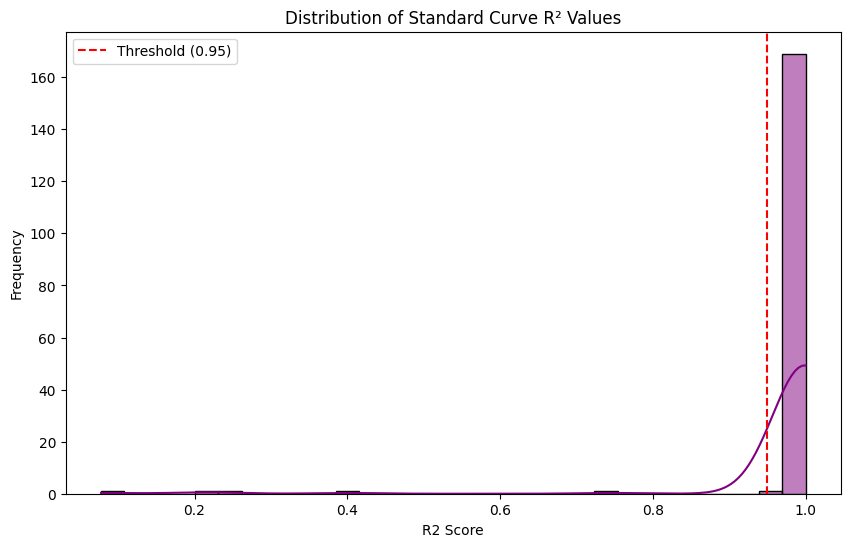

Total Standard Curves evaluated: 175
Average R² Score: 0.9796
Curves failing R² threshold (<0.95): 6

Chips associated with failed curves: ['B72604R8016', 'B72604R8030', 'B52501R8061', 'B72604R8038', 'B72604R8043', 'B72604R8006']
--------------------------------------------------------------------------------
FAILED CURVE DETAILS & PLOTS
--------------------------------------------------------------------------------
Chip ID: B72604R8016 | Curve UUID: csb562a | R²: 0.2006


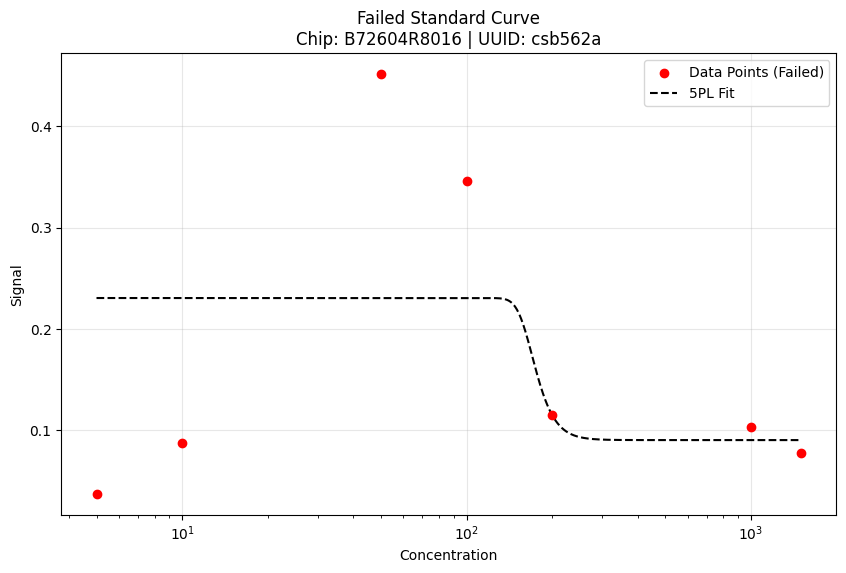

Chip ID: B72604R8030 | Curve UUID: cs36353 | R²: 0.4011


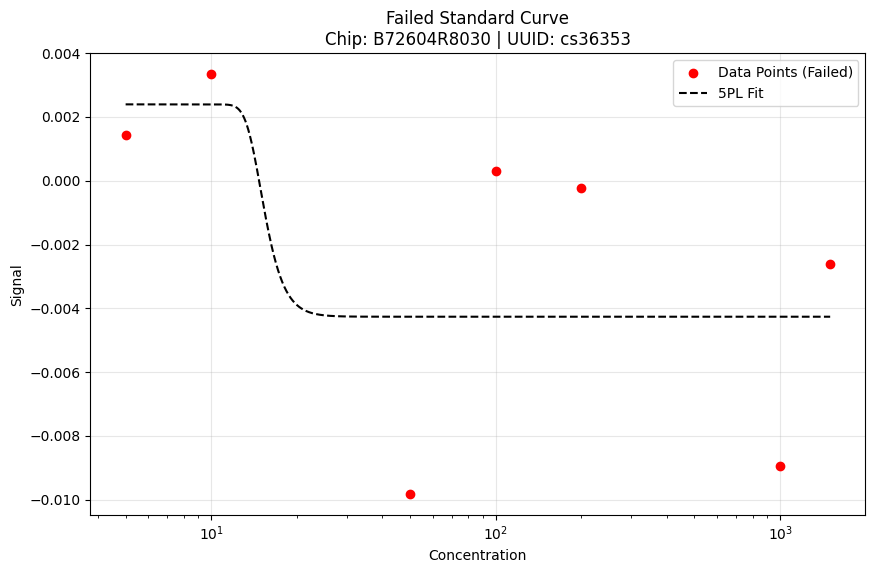

Chip ID: B52501R8061 | Curve UUID: cs84a80 | R²: 0.7446


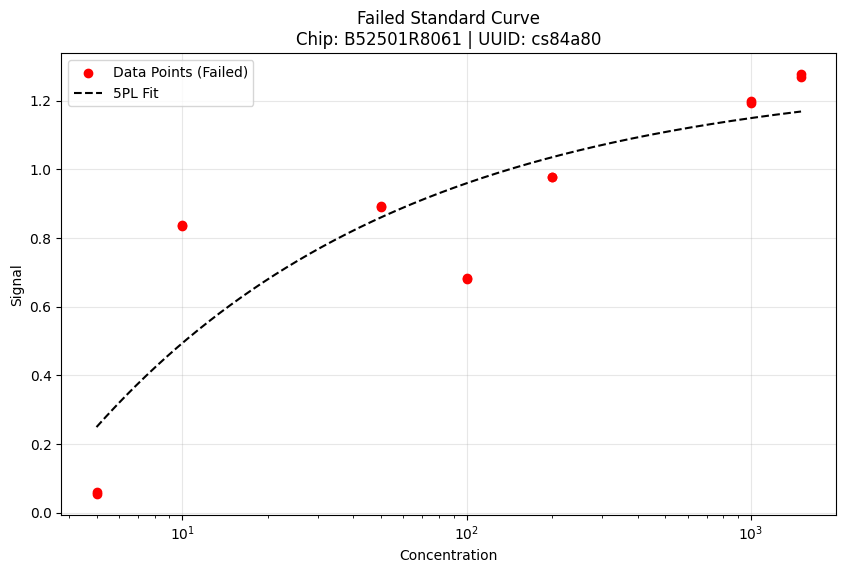

Chip ID: B72604R8038 | Curve UUID: cs2de12 | R²: 0.0775


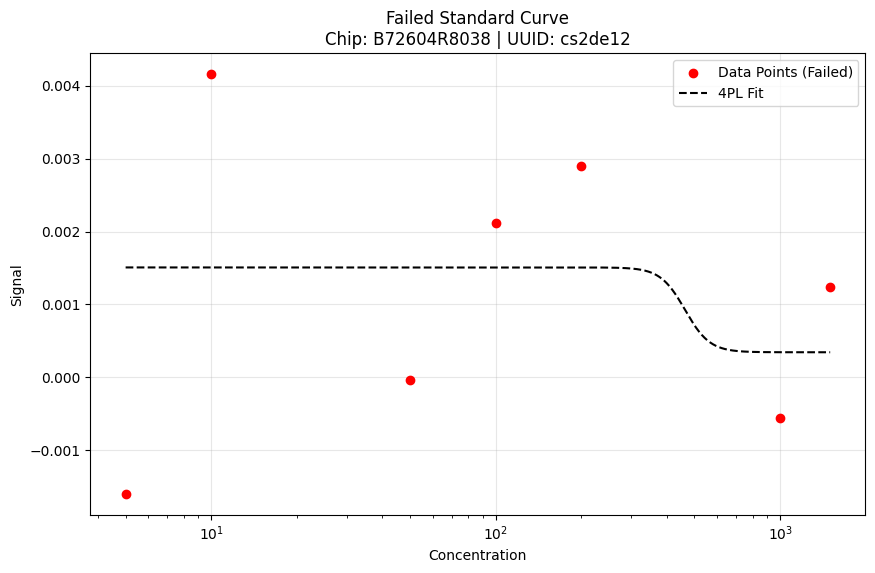

Chip ID: B72604R8043 | Curve UUID: cs419e1 | R²: 0.2325


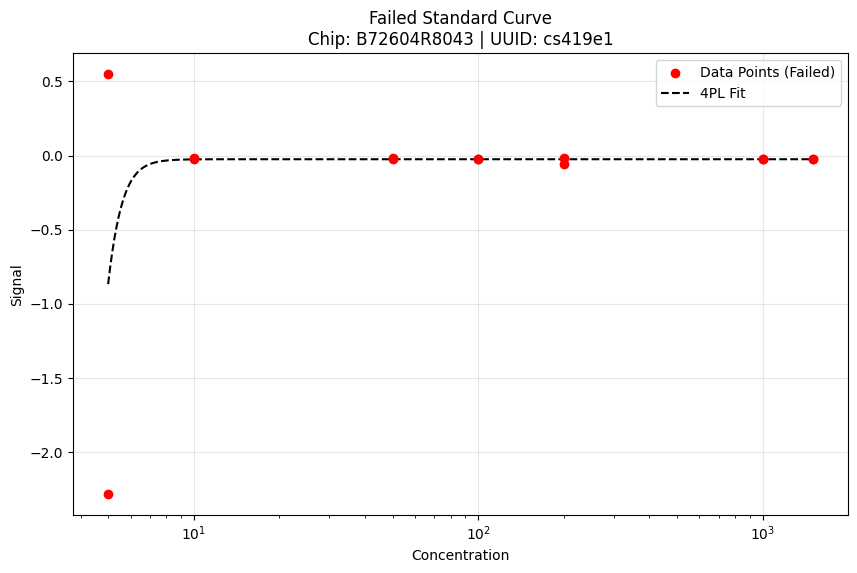

Chip ID: B72604R8006 | Curve UUID: cs5de64 | R²: 0.9463


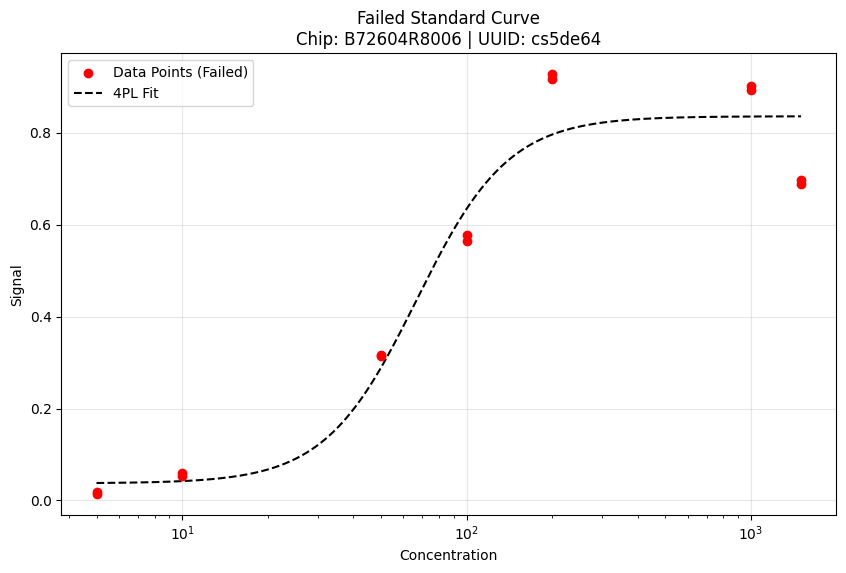

In [374]:
# Evaluates standard-curve quality against the selected R-squared threshold
# Sets the minimum acceptable goodness-of-fit score for a standard curve
r2_threshold = 0.95

# Plots the distribution of standard-curve R-squared scores against the quality threshold
plt.figure(figsize=(10, 6))
sns.histplot(sc_metrics['r2'], bins=30, kde=True, color='purple')
plt.axvline(r2_threshold, color='red', linestyle='--', label=f'Threshold ({r2_threshold})')
plt.title('Distribution of Standard Curve R² Values')
plt.xlabel('R2 Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Identifies curves and chips that fall below the selected R-squared threshold
failing_curves = sc_metrics[sc_metrics['r2'] < r2_threshold]
failing_chips = failing_curves.index.unique().tolist()

print(f'Total Standard Curves evaluated: {len(sc_metrics)}')
print(f"Average R² Score: {sc_metrics['r2'].mean():.4f}")
print(f'Curves failing R² threshold (<{r2_threshold}): {len(failing_curves)}')

# Displays detailed diagnostics only when one or more curves fail the quality check
if failing_chips:
    print(f'\nChips associated with failed curves: {failing_chips}')

    print('-' * 80)
    print('FAILED CURVE DETAILS & PLOTS')
    print('-' * 80)
    
    # Plots the measured points and fitted curve for every failed standard curve
    for chip_id, row in failing_curves.iterrows():

        print(f"Chip ID: {chip_id} | Curve UUID: {row['standard_curve_uuid']} | R²: {row['r2']:.4f}")
        
        pts = np.array(row['points'])
        x_data, y_data = pts[:, 0], pts[:, 1]
        
        xfit = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 1000)
        
        if row['fit_model'] == '5PL':
            yfit = five_pl(xfit, *row['parameters'])
        else:
            yfit = four_pl(xfit, *row['parameters'])
            
        # Plots the failed curve to show where the fitted model differs from the measured response
        plt.figure(figsize=(10, 6))
        plt.scatter(x_data, y_data, color='red', label='Data Points (Failed)', zorder=5)
        plt.plot(xfit, yfit, color='black', linestyle='--', label=f"{row['fit_model']} Fit")
        
        plt.xscale('log')
        plt.title(f"Failed Standard Curve\nChip: {chip_id} | UUID: {row['standard_curve_uuid']}")
        plt.xlabel('Concentration')
        plt.ylabel('Signal')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

## $\color{yellow}{\text{Cross-Stage (PEL + Immob) Analysis}}$

### $\color{red}{\text{Anomalies Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [375]:
# Compares PEL and immediate non-combined immobilisation signals using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], imp_results['channel1']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS]')
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], imp_results['channel2']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS]')

[Immediate (Non-Combined) [ABS] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[Immediate (Non-Combined) [ABS] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


In [376]:
# Compares PEL and immediate non-combined stage changes using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], imp_results['channel1']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta]')
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], imp_results['channel2']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta]')

[Immediate (Non-Combined) [Delta] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[Immediate (Non-Combined) [Delta] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


In [377]:
# Compares PEL and immediate non-combined kinetic features using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], imp_results['channel1']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra]')
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], imp_results['channel2']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra]')

[Immediate (Non-Combined) [Intra] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[Immediate (Non-Combined) [Intra] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


#### $\color{lime}{\text{Immediate (Combined)}}$

In [378]:
# Compares PEL and immediate combined immobilisation signals using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], comb_results['channel1']['wide'], 'Immediate (Combined) [ABS]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [ABS]')
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], comb_results['channel2']['wide'], 'Immediate (Combined) [ABS]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [ABS]')

[Immediate (Combined) [ABS] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[Immediate (Combined) [ABS] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


In [379]:
# Compares PEL and immediate combined stage changes using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], comb_results['channel1']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Delta]')
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], comb_results['channel2']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Delta]')

[Immediate (Combined) [Delta] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[Immediate (Combined) [Delta] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


In [380]:
# Compares PEL and immediate combined kinetic features using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], comb_results['channel1']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Intra]')
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], comb_results['channel2']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Intra]')

[Immediate (Combined) [Intra] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[Immediate (Combined) [Intra] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [381]:
# Compares PEL and five-second non-combined immobilisation signals using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], avg_imp_results['channel1']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Combined) [ABS]')
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], avg_imp_results['channel2']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Combined) [ABS]')

[5s Average (Non-Combined) [ABS] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[5s Average (Non-Combined) [ABS] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


In [382]:
# Compares PEL and five-second non-combined stage changes using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], avg_imp_results['channel1']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Delta]')
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], avg_imp_results['channel2']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Delta]')

[5s Average (Non-Combined) [Delta] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[5s Average (Non-Combined) [Delta] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


In [383]:
# Compares PEL and five-second non-combined kinetic features using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], avg_imp_results['channel1']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Intra]')
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], avg_imp_results['channel2']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Intra]')

[5s Average (Non-Combined) [Intra] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[5s Average (Non-Combined) [Intra] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


#### $\color{lime}{\text{5s Average (Combined)}}$

In [384]:
# Compares PEL and five-second combined immobilisation signals using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], avg_comb_results['channel1']['wide'], '5s Average (Combined) [ABS]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [ABS]')
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], avg_comb_results['channel2']['wide'], '5s Average (Combined) [ABS]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [ABS]')

[5s Average (Combined) [ABS] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[5s Average (Combined) [ABS] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


In [385]:
# Compares PEL and five-second combined stage changes using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], avg_comb_results['channel1']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Delta]')
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], avg_comb_results['channel2']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Delta]')

[5s Average (Combined) [Delta] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[5s Average (Combined) [Delta] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


In [386]:
# Compares PEL and five-second combined kinetic features using PCA
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], avg_comb_results['channel1']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 1', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Intra]')
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], avg_comb_results['channel2']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 2', pel_anomalies, imp_anomalies, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Intra]')

[5s Average (Combined) [Intra] - Channel 1] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.
[5s Average (Combined) [Intra] - Channel 2] Not enough overlapping chips between PEL and Immobilisation for cross-analysis.


### $\color{red}{\text{Correlations Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [387]:
# Calculates cross-stage correlations for immediate non-combined absolute signals
cross_stage_correlations(pel_results['quad_ch1']['wide'], imp_results['channel1']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [ABS]')
cross_stage_correlations(pel_results['quad_ch2']['wide'], imp_results['channel2']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [ABS]')

In [388]:
# Calculates cross-stage correlations for immediate non-combined stage changes
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], imp_results['channel1']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Delta]')
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], imp_results['channel2']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Delta]')

In [389]:
# Calculates cross-stage correlations for immediate non-combined kinetic features
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], imp_results['channel1']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Intra]')
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], imp_results['channel2']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Intra]')

#### $\color{lime}{\text{Immediate (Combined)}}$

In [390]:
# Calculates cross-stage correlations for immediate combined absolute signals
cross_stage_correlations(pel_results['quad_ch1']['wide'], comb_results['channel1']['wide'], 'Immediate (Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [ABS]')
cross_stage_correlations(pel_results['quad_ch2']['wide'], comb_results['channel2']['wide'], 'Immediate (Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [ABS]')

In [391]:
# Calculates cross-stage correlations for immediate combined stage changes
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], comb_results['channel1']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Delta]')
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], comb_results['channel2']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Delta]')

In [392]:
# Calculates cross-stage correlations for immediate combined kinetic features
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], comb_results['channel1']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Intra]')
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], comb_results['channel2']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Intra]')

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [393]:
# Calculates cross-stage correlations for five-second non-combined absolute signals
cross_stage_correlations(pel_results['quad_ch1']['wide'], avg_imp_results['channel1']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Combined) [ABS]')
cross_stage_correlations(pel_results['quad_ch2']['wide'], avg_imp_results['channel2']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Combined) [ABS]')

In [394]:
# Calculates cross-stage correlations for five-second non-combined stage changes
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], avg_imp_results['channel1']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Delta]')
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], avg_imp_results['channel2']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Delta]')

In [395]:
# Calculates cross-stage correlations for five-second non-combined kinetic features
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], avg_imp_results['channel1']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Intra]')
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], avg_imp_results['channel2']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Intra]')

#### $\color{lime}{\text{5s Average (Combined)}}$

In [396]:
# Calculates cross-stage correlations for five-second combined absolute signals
cross_stage_correlations(pel_results['quad_ch1']['wide'], avg_comb_results['channel1']['wide'], '5s Average (Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [ABS]')
cross_stage_correlations(pel_results['quad_ch2']['wide'], avg_comb_results['channel2']['wide'], '5s Average (Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [ABS]')

In [397]:
# Calculates cross-stage correlations for five-second combined stage changes
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], avg_comb_results['channel1']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Delta]')
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], avg_comb_results['channel2']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Delta]')

In [398]:
# Calculates cross-stage correlations for five-second combined kinetic features
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], avg_comb_results['channel1']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Intra]')
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], avg_comb_results['channel2']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Intra]')

## $\color{yellow}{\text{Interactive Stage Comparison Dashboards}}$

### $\color{red}{\text{Setup}}$

In [399]:
# Copies the fit metrics so the original standard-curve results remain unchanged
sc_copy = sc_metrics.copy()
sc_copy.columns = sc_copy.columns.astype(str)

# Selects only numeric fit metrics that can be compared with the stage-analysis datasets
numeric_cols = sc_copy.select_dtypes(include='number').columns.tolist()

# Retains the timestamp temporarily so the first curve for each chip can be selected
if 'datetime' in sc_copy.columns:
    sc_copy = sc_copy[['datetime'] + numeric_cols]
else:
    sc_copy = sc_copy[numeric_cols]

# Keeps the first standard-curve record per chip for cross-stage comparisons
sc_first = sc_copy.sort_values('datetime').groupby(sc_copy.index, sort=False).first().drop(columns='datetime')

In [400]:
# Builds a catalog of analysis datasets for the interactive dashboard
master_data_catalog = {

    # Stores absolute-signal datasets for dashboard comparisons
    'Absolute': {
        'PEL': {'Channel 1': pel_results['quad_ch1']['wide'], 'Channel 2': pel_results['quad_ch2']['wide']},
        'Immob (Imm, Non-Comb)': {'Channel 1': imp_results['channel1']['wide'], 'Channel 2': imp_results['channel2']['wide']},
        'Immob (Imm, Comb)': {'Channel 1': comb_results['channel1']['wide'], 'Channel 2': comb_results['channel2']['wide']},
        'Immob (5s, Non-Comb)': {'Channel 1': avg_imp_results['channel1']['wide'], 'Channel 2': avg_imp_results['channel2']['wide']},
        'Immob (5s, Comb)': {'Channel 1': avg_comb_results['channel1']['wide'], 'Channel 2': avg_comb_results['channel2']['wide']},
        'Standard Curve': {'Channel 1': sc_first} 
    },

    # Stores stage-to-stage signal-change datasets for dashboard comparisons
    'Stage Delta': {
        'PEL': {'Channel 1': pel_results['quad_ch1']['change_wide'], 'Channel 2': pel_results['quad_ch2']['change_wide']},
        'Immob (Imm, Non-Comb)': {'Channel 1': imp_results['channel1']['change_wide'], 'Channel 2': imp_results['channel2']['change_wide']},
        'Immob (Imm, Comb)': {'Channel 1': comb_results['channel1']['change_wide'], 'Channel 2': comb_results['channel2']['change_wide']},
        'Immob (5s, Non-Comb)': {'Channel 1': avg_imp_results['channel1']['change_wide'], 'Channel 2': avg_imp_results['channel2']['change_wide']},
        'Immob (5s, Comb)': {'Channel 1': avg_comb_results['channel1']['change_wide'], 'Channel 2': avg_comb_results['channel2']['change_wide']},
        'Standard Curve': {'Channel 1': sc_first}
    },
    
    # Stores within-stage kinetic feature datasets for dashboard comparisons
    'Intra-stage Kinetics': {
        'PEL': {'Channel 1': pel_results['quad_ch1']['intra_wide'], 'Channel 2': pel_results['quad_ch2']['intra_wide']},
        'Immob (Imm, Non-Comb)': {'Channel 1': imp_results['channel1']['intra_wide'], 'Channel 2': imp_results['channel2']['intra_wide']},
        'Immob (Imm, Comb)': {'Channel 1': comb_results['channel1']['intra_wide'], 'Channel 2': comb_results['channel2']['intra_wide']},
        'Immob (5s, Non-Comb)': {'Channel 1': avg_imp_results['channel1']['intra_wide'], 'Channel 2': avg_imp_results['channel2']['intra_wide']},
        'Immob (5s, Comb)': {'Channel 1': avg_comb_results['channel1']['intra_wide'], 'Channel 2': avg_comb_results['channel2']['intra_wide']},
        'Standard Curve': {'Channel 1': sc_first}
    }
}

In [401]:
# Save the catalog
with open('dashboard_catalog.pkl', 'wb') as f:
    pickle.dump(master_data_catalog, f)

### $\color{red}{\text{Display}}$

In [402]:
# Launches the interactive cross-stage data exploration dashboard
create_interactive_dashboard(master_data_catalog)

HTML(value="<h3 style='margin-bottom:0px; color:#0000FF;'>Master Chip Comparison Dashboard</h3>")

Output()

# $\color{orange}{\text{Overall Summary}}$

---

## $\color{yellow}{\text{Setup}}$

In [404]:
section_config = {
    'PEL Absolute (Ch1)': prepare_section(pel_events_norm, 'stage', 'quad_ch1'),
    'PEL Delta (Ch1)': prepare_section(pel_changes, 'stage', 'quad_ch1_change'),
    'PEL Intra-stage Kinetics (Ch1)': prepare_section(pel_intra, 'stage', 'quad_ch1_std'),

    'PEL Absolute (Ch2)': prepare_section(pel_events_norm, 'stage', 'quad_ch2'),
    'PEL Delta (Ch2)': prepare_section(pel_changes, 'stage', 'quad_ch2_change'),
    'PEL Intra-stage Kinetics (Ch2)': prepare_section(pel_intra, 'stage', 'quad_ch2_std'),

    'Immob Immediate Abs Non-Comb (Ch1)': prepare_section(imp_norm, 'stage', 'channel1'),
    'Immob Immediate Delta Non-Comb (Ch1)': prepare_section(imp_changes, 'stage', 'channel1_change'),
    'Immob Immediate Intra-stage Non-Comb (Ch1)': prepare_section(imp_intra, 'stage', 'channel1_std'),

    'Immob Immediate Abs Non-Comb (Ch2)': prepare_section(imp_norm, 'stage', 'channel2'),
    'Immob Immediate Delta Non-Comb (Ch2)': prepare_section(imp_changes, 'stage', 'channel2_change'),
    'Immob Immediate Intra-stage Non-Comb (Ch2)': prepare_section(imp_intra, 'stage', 'channel2_std'),

    'Immob Immediate Abs Comb (Ch1)': prepare_section(comb_norm, 'stage', 'channel1'),
    'Immob Immediate Delta Comb (Ch1)': prepare_section(comb_changes, 'stage', 'channel1_change'),
    'Immob Immediate Intra-stage Comb (Ch1)': prepare_section(comb_intra, 'stage', 'channel1_std'),

    'Immob Immediate Abs Comb (Ch2)': prepare_section(comb_norm, 'stage', 'channel2'),
    'Immob Immediate Delta Comb (Ch2)': prepare_section(comb_changes, 'stage', 'channel2_change'),
    'Immob Immediate Intra-stage Comb (Ch2)': prepare_section(comb_intra, 'stage', 'channel2_std'),

    'Immob 5s Avg Abs Non-Comb (Ch1)': prepare_section(avg_imp_norm, 'stage', 'channel1'),
    'Immob 5s Avg Delta Non-Comb (Ch1)': prepare_section(avg_imp_changes, 'stage', 'channel1_change'),
    'Immob 5s Avg Intra-stage Non-Comb (Ch1)': prepare_section(avg_imp_intra, 'stage', 'channel1_std'),

    'Immob 5s Avg Abs Non-Comb (Ch2)': prepare_section(avg_imp_norm, 'stage', 'channel2'),
    'Immob 5s Avg Delta Non-Comb (Ch2)': prepare_section(avg_imp_changes, 'stage', 'channel2_change'),
    'Immob 5s Avg Intra-stage Non-Comb (Ch2)': prepare_section(avg_imp_intra, 'stage', 'channel2_std'),

    'Immob 5s Avg Abs Comb (Ch1)': prepare_section(avg_comb_norm, 'stage', 'channel1'),
    'Immob 5s Avg Delta Comb (Ch1)': prepare_section(avg_comb_changes, 'stage', 'channel1_change'),
    'Immob 5s Avg Intra-stage Comb (Ch1)': prepare_section(avg_comb_intra, 'stage', 'channel1_std'),

    'Immob 5s Avg Abs Comb (Ch2)': prepare_section(avg_comb_norm, 'stage', 'channel2'),
    'Immob 5s Avg Delta Comb (Ch2)': prepare_section(avg_comb_changes, 'stage', 'channel2_change'),
    'Immob 5s Avg Intra-stage Comb (Ch2)': prepare_section(avg_comb_intra, 'stage', 'channel2_std')
}

DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 24)


stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG over chip 1,PrG over chip 1 - Plateau,PrG over chip 2,PrG over chip 2 - Plateau,PrG over chip 3,PrG over chip 3 - Plateau,PrG over chip 4,PrG over chip 4 - Plateau,PrG over chip 5,PrG over chip 5 - Plateau,PrG over chip 6,PrG over chip 6 - Plateau,Baseline - PrG over chip 6,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,0.037115,1.771707,0.356,0.361929,0.383999,0.402098,0.407402,0.429634,0.468092,0.468496,0.514767,0.515234,0.534073,0.559087,0.548464,0.610,0.645965,3.349749,0.149,0.181350,0.388253,0.221,0.222,NaN
B72604R8027,-0.037990,1.539781,0.538,0.540653,1.431889,1.441478,1.951463,1.951820,2.099374,2.114083,2.218532,2.218337,2.287070,2.324441,2.391857,2.437,2.452811,4.607474,1.895,1.933777,2.424957,2.280,2.263,NaN
B72604R8028,0.004654,1.984243,0.656,0.664972,1.357719,1.355269,1.968943,1.964115,2.253122,2.246014,2.394694,2.402318,2.507932,2.514571,2.606532,2.665,2.669571,5.152726,2.206,2.198187,2.741170,2.568,2.586,NaN
B72604R8029,0.013931,2.257665,0.590,0.584793,1.454175,1.440167,1.925918,1.931608,2.048008,2.040495,2.176711,2.168058,2.261402,2.270693,2.338984,2.388,2.431107,4.881829,1.845,1.825845,2.369343,2.275,2.260,NaN
B72604R8030,0.184847,2.307444,0.672,0.681773,1.661626,1.656295,2.193812,2.189083,2.362031,2.354892,2.495983,2.497241,2.615113,2.616870,2.698776,2.727,3.626434,5.225504,2.317,2.328599,2.898285,2.722,-21.317,NaN
B72604R8032,-0.016818,2.271165,0.605,0.594255,2.016000,2.028875,2.205396,2.213061,2.336651,2.330553,2.444807,2.439899,2.533424,2.530104,2.605129,2.646,2.763434,5.265561,2.215,2.191658,2.739725,2.572,2.597,NaN
B72604R8034,-0.014235,2.488696,0.570,0.587675,1.461232,1.475489,1.917609,1.942937,2.076200,2.090187,2.183635,2.176886,2.243273,2.267704,2.340440,2.374,3.032636,5.019289,1.883,1.905881,2.376474,-20.763,-20.763,NaN
B72604R8035,0.008819,1.114935,0.393,0.389494,0.380000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,-0.024294,2.207415,0.593,0.579562,1.333140,1.333312,1.717113,1.724477,1.843105,1.835570,1.927142,1.927160,2.015663,2.021979,2.114387,2.174,2.169765,4.533139,1.692,1.675254,2.110212,1.965,1.947,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 30)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG over chip 1,PrG over chip 1 -> PrG over chip 1 - Plateau,PrG over chip 1 - Plateau -> PrG over chip 2,PrG over chip 2 -> PrG over chip 2 - Plateau,PrG over chip 2 - Plateau -> PrG over chip 3,PrG over chip 3 -> PrG over chip 3 - Plateau,PrG over chip 3 - Plateau -> PrG over chip 4,PrG over chip 4 -> PrG over chip 4 - Plateau,PrG over chip 4 - Plateau -> PrG over chip 5,PrG over chip 5 -> PrG over chip 5 - Plateau,PrG over chip 5 - Plateau -> PrG over chip 6,PrG over chip 6 -> PrG over chip 6 - Plateau,PrG over chip 6 - Plateau -> Baseline - PrG over chip 6,Baseline - PrG over chip 6 -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - PrG over chip 6,Net_Shift_Baseline - PrG over chip 6_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B72604R8011,24.543,0.037115,1.734592,-1.415707,0.005929,0.022069,0.018099,0.005304,0.022231,0.038459,0.000403,0.046271,0.000467,0.018839,0.025015,-0.010624,0.061536,0.035965,2.703785,-3.200749,0.032350,0.206903,-0.167253,0.001,0.356,0.254,-0.461,0.072,0.221,NaN
B72604R8027,-0.610,-0.037990,1.577771,-1.001781,0.002653,0.891236,0.009589,0.509985,0.000357,0.147554,0.014710,0.104448,-0.000195,0.068734,0.037371,0.067416,0.045143,0.015811,2.154662,-2.712474,0.038777,0.491180,-0.144957,-0.017,0.538,1.899,-0.542,0.385,2.280,NaN
B72604R8028,-0.546,0.004654,1.979589,-1.328243,0.008972,0.692747,-0.002450,0.613674,-0.004828,0.289007,-0.007108,0.148680,0.007624,0.105613,0.006639,0.091961,0.058468,0.004571,2.483155,-2.946726,-0.007813,0.542983,-0.173170,0.018,0.656,2.009,-0.459,0.362,2.568,NaN
B72604R8029,-0.059,0.013931,2.243734,-1.667665,-0.005207,0.869382,-0.014008,0.485751,0.005690,0.116400,-0.007513,0.136215,-0.008653,0.093344,0.009291,0.068291,0.049016,0.043107,2.450722,-3.036829,-0.019155,0.543498,-0.094343,-0.015,0.590,1.798,-0.543,0.430,2.275,NaN
B72604R8030,-0.062,0.184847,2.122598,-1.635444,0.009773,0.979853,-0.005332,0.537518,-0.004729,0.172948,-0.007139,0.141091,0.001258,0.117872,0.001757,0.081906,0.028224,0.899434,1.599070,-2.908504,0.011599,0.569687,-0.176285,-24.039,0.672,2.055,-0.410,0.405,2.722,NaN
B72604R8032,-0.164,-0.016818,2.287983,-1.666165,-0.010745,1.421745,0.012875,0.176521,0.007664,0.123591,-0.006099,0.114255,-0.004908,0.093524,-0.003320,0.075024,0.040871,0.117434,2.502127,-3.050561,-0.023342,0.548067,-0.167725,0.025,0.605,2.041,-0.431,0.357,2.572,NaN
B72604R8034,-0.138,-0.014235,2.502931,-1.918696,0.017675,0.873557,0.014257,0.442120,0.025328,0.133263,0.013987,0.093448,-0.006750,0.066387,0.024431,0.072736,0.033560,0.658636,1.986653,-3.136289,0.022881,0.470593,-23.139474,0.000,0.570,1.804,-0.491,-22.646,-20.763,NaN
B72604R8035,-0.008,0.008819,1.106116,-0.721935,-0.003506,-0.009494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.393,NaN,NaN,NaN,0.393,NaN
B72604R8037,-1.679,-0.024294,2.231709,-1.614415,-0.013438,0.753578,0.000172,0.383800,0.007364,0.118628,-0.007536,0.091573,0.000018,0.088503,0.006316,0.092408,0.059613,-0.004235,2.363374,-2.841139,-0.016746,0.434959,-0.145212,-0.018,0.593,1.581,-0.482,0.273,1.965,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 24)


...

stage,Buffer 1 - NHS EDC,Buffer 1 - Plateau,Baseline - Buffer 1,PrG,PrG - Plateau,Buffer 2 - ETA,Buffer 2 - Plateau,Baseline - Buffer 2,Buffer 3 - Casein Block,Buffer 3 - Plateau,Final,Finish,Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,
B72604R8011,1.388128,1.784311,0.366641,0.393310,0.560080,2.687494,3.361805,0.157807,0.341937,0.402414,0.229433,0.232222,NaN
B72604R8027,1.336068,1.947635,0.585950,0.613707,2.506661,4.409201,4.668868,1.513284,1.828686,2.295705,2.059368,2.060137,NaN
B72604R8028,1.546824,1.706117,0.549936,0.552995,2.401151,4.656009,4.813225,1.974846,2.129443,2.460237,2.300660,2.315152,NaN
B72604R8029,2.125793,2.732200,0.810560,0.826930,2.869430,4.796382,5.343509,2.359067,2.522208,2.959308,2.833884,2.829405,NaN
B72604R8030,2.183443,2.304986,0.673650,0.692250,2.710001,5.187894,5.219651,2.305787,2.529124,2.902453,2.715776,-21.318475,NaN
B72604R8032,1.829416,2.670142,0.782491,0.793185,3.116159,5.138380,5.598583,2.672038,2.883865,3.257854,3.074852,3.071628,NaN
B72604R8034,2.054491,2.692933,0.769928,0.785851,2.763367,4.774561,5.154966,2.498502,2.680068,2.997979,-28.147645,-28.147645,NaN
B72604R8035,1.313965,1.926463,1.092668,1.080501,1.091304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B72604R8037,1.683377,2.203479,0.574375,0.597095,2.103237,4.112473,4.524503,1.678564,1.882905,2.103410,1.952308,1.944601,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 18)


stage,Start -> Initial,Initial -> Buffer 1 - NHS EDC,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Baseline - Buffer 1 -> PrG,PrG -> PrG - Plateau,PrG - Plateau -> Buffer 2 - ETA,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Net_Shift_Initial_to_Baseline - Buffer 1,Net_Shift_Baseline - Buffer 1_to_Baseline - Buffer 2,Net_Shift_Baseline - Buffer 2_to_Final,Total_Shift_Initial_to_Final,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau
chip_id,,,,,,,,,,,,,,,,,,
B72604R8011,24.532778,1.388128,0.396182,-1.417670,0.026669,0.166770,2.127414,0.674311,-3.203998,0.184129,0.060477,-0.172981,0.002790,0.366641,-0.208834,0.071625,0.229433,NaN
B72604R8027,0.537863,1.336068,0.611567,-1.361685,0.027758,1.892953,1.902540,0.259668,-3.155585,0.315402,0.467019,-0.236337,0.000769,0.585950,0.927334,0.546084,2.059368,NaN
B72604R8028,-0.657152,1.546824,0.159292,-1.156180,0.003059,1.848156,2.254858,0.157216,-2.838379,0.154597,0.330795,-0.159578,0.014492,0.549936,1.424909,0.325814,2.300660,NaN
B72604R8029,-0.057405,2.125793,0.606407,-1.921640,0.016369,2.042500,1.926953,0.547127,-2.984442,0.163141,0.437100,-0.125424,-0.004479,0.810560,1.548506,0.474817,2.833884,NaN
B72604R8030,-0.052525,2.183443,0.121543,-1.631336,0.018600,2.017751,2.477893,0.031757,-2.913863,0.223337,0.373328,-0.186676,-24.034252,0.673650,1.632138,0.409989,2.715776,NaN
B72604R8032,-0.203628,1.829416,0.840726,-1.887651,0.010694,2.322974,2.022221,0.460203,-2.926544,0.211826,0.373989,-0.183002,-0.003224,0.782491,1.889547,0.402813,3.074852,NaN
B72604R8034,-0.130355,2.054491,0.638442,-1.923006,0.015924,1.977516,2.011194,0.380405,-2.656464,0.181566,0.317911,-31.145624,0.000000,0.769928,1.728574,-30.646146,-28.147645,NaN
B72604R8035,-0.018655,1.313965,0.612498,-0.833795,-0.012167,0.010803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.092668,NaN,NaN,1.092668,NaN
B72604R8037,-1.680601,1.683377,0.520103,-1.629104,0.022720,1.506142,2.009235,0.412031,-2.845939,0.204341,0.220505,-0.151102,-0.007707,0.574375,1.104190,0.273744,1.952308,NaN


DEBUG: Chip B72604R8035 entered anomaly detection with shape (1, 14)


stage,Baseline - Buffer 1 -> PrG,Baseline - Buffer 2 -> Buffer 3 - Casein Block,Buffer 1 - NHS EDC -> Buffer 1 - Plateau,Buffer 1 - Plateau -> Baseline - Buffer 1,Buffer 2 - ETA -> Buffer 2 - ETA - Plateau,Buffer 2 - ETA -> Buffer 2 - Plateau,Buffer 2 - Plateau -> Baseline - Buffer 2,Buffer 3 - Casein Block -> Buffer 3 - Plateau,Buffer 3 - Plateau -> Final,Final -> Finish,Initial -> Buffer 1 - NHS EDC,PrG - Plateau -> Buffer 2 - ETA,PrG -> PrG - Plateau,Start -> Initial
chip_id,,,,,,,,,,,,,,
B72604R8011,0.007262,0.872224,0.067292,0.455907,NaN,0.008432,1.272540,0.095599,0.064411,0.008704,0.228886,0.195902,0.028201,3.366351
B72604R8027,0.012891,0.130781,0.045315,0.458885,NaN,0.017458,1.376148,0.046326,0.025528,0.010754,0.183197,0.165594,0.449471,0.308864
B72604R8028,0.004608,0.064161,0.035212,0.382753,NaN,0.053781,1.267045,0.054547,0.057728,0.006667,0.338569,0.228108,0.355911,0.306991
B72604R8029,0.010273,0.054867,0.092065,0.580520,NaN,0.020709,1.353810,0.041040,0.038478,0.010332,0.520151,0.175954,0.463019,0.019596
B72604R8030,0.004404,0.075111,0.085102,0.527707,NaN,0.019968,1.300148,0.037597,0.019964,2.194084,1.030186,0.179146,0.422855,0.015570
B72604R8032,0.010387,0.080420,0.090334,0.578715,NaN,0.020858,1.315710,0.029506,0.031603,0.009464,0.379696,0.179053,0.392400,0.054493
B72604R8034,0.011935,0.070892,0.091036,0.554729,NaN,0.031797,1.178061,0.034468,15.513252,0.000000,0.392405,0.185455,0.449561,0.039902
B72604R8035,0.008449,NaN,0.175207,0.396130,NaN,NaN,NaN,NaN,NaN,NaN,0.272305,NaN,0.013471,0.011554
B72604R8037,0.007675,0.078421,0.057872,0.506815,NaN,0.009826,1.203379,0.020110,0.038441,0.007610,0.423564,0.137968,0.315983,0.773314


In [405]:
# Collects every chip identified as anomalous or chips with a standard-curve at risk
all_at_risk_chips = set(failing_chips)

# Loops through each section configuration to aggregate outlier chips
for _, outliers in section_config.values():
    all_at_risk_chips.update(outliers)

# Adds incomplete chips
'''all_at_risk_chips.update(all_incomplete_chips)

print(len(all_at_risk_chips))'''

'all_at_risk_chips.update(all_incomplete_chips)\n\nprint(len(all_at_risk_chips))'

In [406]:
pel_1 = section_config['PEL Absolute (Ch1)'][0].copy().add_suffix('_PEL_Ch1')
pel_2 = section_config['PEL Absolute (Ch2)'][0].copy().add_suffix('_PEL_Ch2')

pel_intra_1 = section_config['PEL Intra-stage Kinetics (Ch1)'][0].copy().add_suffix('_PEL_Intra_Ch1')
pel_intra_2 = section_config['PEL Intra-stage Kinetics (Ch2)'][0].copy().add_suffix('_PEL_Intra_Ch2')

immob_1 = section_config['Immob Immediate Abs Non-Comb (Ch1)'][0].copy().add_suffix('_Immob_Ch1')
immob_2 = section_config['Immob Immediate Abs Non-Comb (Ch2)'][0].copy().add_suffix('_Immob_Ch2')

immob_intra_1 = section_config['Immob Immediate Intra-stage Non-Comb (Ch1)'][0].copy().add_suffix('_Immob_Intra_Ch1')
immob_intra_2 = section_config['Immob Immediate Intra-stage Non-Comb (Ch2)'][0].copy().add_suffix('_Immob_Intra_Ch2')

master_df = pd.concat([pel_1, pel_2, pel_intra_1, pel_intra_2, immob_1, immob_2, immob_intra_1, immob_intra_2], axis=1, join='inner')

print(len(master_df))

28


## $\color{yellow}{\text{Chips That May Fail}}$

In [407]:
# Generates a detailed summary of at-risk chips and their anomaly drivers
generate_at_risk_summary(master_df, sc_metrics, tables['standard_curves'], all_at_risk_chips, section_config, all_incomplete_chips, 'At-Risk Chips & Anomaly Drivers')

# $\color{orange}{\text{Standard Curve Extra Data (Single Chip)}}$

---

## $\color{yellow}{\text{Getting SC Data}}$

In [408]:
# Loads local standard-curve CSV files into a structured dictionary
# Sets the directory containing exported standard-curve measurements
base_dir = 'Standard Curve Files'

# Creates a nested dictionary to organise files by their export folder
files = {}

# Loops through each export folder and loads its CSV measurements
for folder in os.listdir(base_dir):

    # Builds the full path for the current export folder
    folder_path = os.path.join(base_dir, folder)

    # Checks if the folder path exists
    if os.path.isdir(folder_path):
        files[folder] = {}

        # Loops through each CSV candidate in the current export folder
        for file in os.listdir(folder_path):

            # Builds the full path for the current CSV file
            file_path = os.path.join(folder_path, file)

            # Loads CSV files only because they contain the standard-curve measurements
            if file.endswith('.csv'):
                
                # Removes the extension so the dictionary key matches the measurement name
                file_name = os.path.splitext(file)[0]

                df = pd.read_csv(file_path)

                # Repairs missing sensorgram headers so channel data can be analysed consistently
                if 'sensorgram' in file_name.lower():
                    expected = ['time', 'channel1', 'channel2']

                    if list(df.columns[:2]) != expected:
                        df = pd.read_csv(file_path, header=None)
                        df.columns = expected

                # Stores the loaded dataframe under its folder and measurement name
                files[folder][file_name] = df

## $\color{yellow}{\text{Basic Analysis}}$

In [409]:
# Runs extended standard-curve visualisations and baseline-shift analysis
files = analyse_standard_curves_extra(files)

Calculated flags for 2026-04-13/Copy of B52501R8242_csa5eb7_sensorgram
Calculated flags for 2026-04-13/Copy of B52501R8242_csda3af_sensorgram
Calculated flags for 2026-04-15/Copy of B52501R8242_cs5dbc5_sensorgram
Calculated flags for 2026-04-16/Copy of B52501R8242_cs3142c_sensorgram

Evaluating Folder: 2026-04-13

--- Chip ID: B52501R8242 | Measurement ID: csa5eb7 ---



--- Chip ID: B52501R8242 | Measurement ID: csda3af ---



Evaluating Folder: 2026-04-15

--- Chip ID: B52501R8242 | Measurement ID: cs5dbc5 ---



Evaluating Folder: 2026-04-16

--- Chip ID: B52501R8242 | Measurement ID: cs3142c ---


## $\color{yellow}{\text{Binding Kinetics}}$

In [410]:
# Runs association and dissociation binding-kinetics analysis
kinetics_results = run_binding_kinetics_analysis(files)


Overall Kinetics Distributions



Kinetics Analysis: 2026-04-13



--- Chip ID: B52501R8242 | Measurement ID: csa5eb7 ---



--- Chip ID: B52501R8242 | Measurement ID: csda3af ---



Kinetics Analysis: 2026-04-15



--- Chip ID: B52501R8242 | Measurement ID: cs5dbc5 ---



Kinetics Analysis: 2026-04-16



--- Chip ID: B52501R8242 | Measurement ID: cs3142c ---


# $\color{orange}{\text{Standard Curve Extra Data (Multi-Chip)}}$

---

finalise the baseline finds

another thing to mention is shouldnt k_d be negative since decrease and k_a psotive since increase

## $\color{yellow}{\text{Getting SC Data}}$

In [420]:
# Loads local standard-curve CSV files into a structured dictionary
# Sets the directory containing exported standard-curve measurements
base_dir2 = 'SCs'

# Creates a nested dictionary to organise files by their export folder
files2 = {}

# Loops through each export folder and loads its CSV measurements
for folder in os.listdir(base_dir2):

    # Builds the full path for the current export folder
    folder_path = os.path.join(base_dir2, folder)

    # Checks if the folder path exists
    if os.path.isdir(folder_path):
        files2[folder] = {}

        # Loops through each CSV candidate in the current export folder
        for file in os.listdir(folder_path):

            # Builds the full path for the current CSV file
            file_path = os.path.join(folder_path, file)

            # Loads CSV files only because they contain the standard-curve measurements
            if file.endswith('.csv'):
                
                # Removes the extension so the dictionary key matches the measurement name
                file_name = os.path.splitext(file)[0]

                df = pd.read_csv(file_path)

                # Repairs missing sensorgram headers so channel data can be analysed consistently
                if 'sensorgram' in file_name.lower():
                    expected = ['time', 'channel1', 'channel2']

                    if list(df.columns[:2]) != expected:
                        df = pd.read_csv(file_path, header=None)
                        df.columns = expected

                # Stores the loaded dataframe under its folder and measurement name
                files2[folder][file_name] = df

## $\color{yellow}{\text{Basic Analysis}}$

In [427]:
# Runs extended standard-curve visualisations and baseline-shift analysis
files2 = analyse_standard_curves_extra(files2, base_dir2)

Calculated flags for B72604R8008/B72604R8008_cs38715_sensorgram
Calculated flags for B72604R8027/B72604R8027_csd2936_sensorgram
Calculated flags for B72604R8029/B72604R8029_cs1d4e9_sensorgram
Calculated flags for B72604R8037/B72604R8037_csa61e0_sensorgram
Calculated flags for B72604R8038/B72604R8038_csfa2c3_sensorgram
Calculated flags for B72604R8042/B72604R8042_cs09963_sensorgram
Calculated flags for B72604R8042/B72604R8042_cs21db5_sensorgram
Calculated flags for B72604R8042/B72604R8042_cs54a64_sensorgram
Calculated flags for B72604R8042/B72604R8042_cs608ce_sensorgram
Calculated flags for B72604R8042/B72604R8042_cs69ed7_sensorgram
Calculated flags for B72604R8042/B72604R8042_csf6681_sensorgram
Calculated flags for B72604R8043/B72604R8043_cs2666e_sensorgram
Calculated flags for B72604R8047/B72604R8047_csb9761_sensorgram
Calculated flags for B72604R8053/B72604R8053_cs95767_sensorgram
Calculated flags for B72604R8055/B72604R8055_cs68f31_sensorgram
Calculated flags for B72604R81032/B72604


Evaluating Folder: B72604R8027

--- Chip ID: B72604R8027 | Measurement ID: csd2936 ---


KeyboardInterrupt: 

## $\color{yellow}{\text{Binding Kinetics}}$

In [ ]:
# Runs association and dissociation binding-kinetics analysis
kinetics_results = run_binding_kinetics_analysis(files2)


Overall Kinetics Distributions



Kinetics Analysis: B52501R8242

Kinetics Analysis: B72604R8008



--- Chip ID: B72604R8008 | Measurement ID: cs38715 ---



Kinetics Analysis: B72604R8027



--- Chip ID: B72604R8027 | Measurement ID: csd2936 ---


...


--- Chip ID: B72604R8110 | Measurement ID: cs4fc25 ---



Kinetics Analysis: B72604R8112



--- Chip ID: B72604R8112 | Measurement ID: cs9bb12 ---



Kinetics Analysis: B72604R8138



--- Chip ID: B72604R8138 | Measurement ID: cse0631 ---


# $\color{cyan}{\text{Run Check}}$

In [ ]:
# Confirms that the primary analysis workflow has completed
print('run completed')

run completed


## $\color{yellow}{\text{Seperate}}$

In [ ]:
# Counts the initial channel ordering across PEL sensorgram files
total_ch1_less = 0
total_ch2_less = 0
total_equal = 0

# Loops through each key and value in the dictionary
for file_name, file_data in bucket_data['Sensorgram'].items():

    if file_data['quad_ch1'].iloc[0] < file_data['quad_ch2'].iloc[0]:
        total_ch1_less += 1
    elif file_data['quad_ch1'].iloc[0] > file_data['quad_ch2'].iloc[0]:
        total_ch2_less += 1
    else:
        total_equal += 1

# Prints Summary
print('Ch1 < Ch2: ', total_ch1_less)
print('Ch1 > Ch2: ', total_ch2_less)
print('Ch1 = Ch2: ', total_equal)

Ch1 < Ch2:  173
Ch1 > Ch2:  10
Ch1 = Ch2:  4


In [ ]:
# Counts the initial channel ordering across RefPoly4 immobilisation files
total_ch1_less = 0
total_ch2_less = 0
total_equal = 0

# Loops through each key and value in the dictionary
for file_name, file_data in bucket_data['RefPoly4'].items():

    if file_data['channel1'].iloc[0] < file_data['channel2'].iloc[0]:
        total_ch1_less += 1
    elif file_data['channel1'].iloc[0] > file_data['channel2'].iloc[0]:
        total_ch2_less += 1
    else:
        total_equal += 1

# Prints Summary
print('Ch1 < Ch2: ', total_ch1_less)
print('Ch1 > Ch2: ', total_ch2_less)
print('Ch1 = Ch2: ', total_equal)

Ch1 < Ch2:  28
Ch1 > Ch2:  4
Ch1 = Ch2:  0


## $\color{yellow}{\text{Overall}}$

In [ ]:
# Initialises variables to track channel-order changes between matched records
total_less_more = 0
total_more_less = 0
total_less = 0
total_more = 0

# Initialises variables to count initial PEL channel ordering
pel_ch1_less = 0
pel_ch2_less = 0
pel_equal = 0

# Initialises variables to count initial immobilisation channel ordering
immob_ch1_less = 0
immob_ch2_less = 0
immob_equal = 0

# Initialises variables to track record matching success
total_not_matched = 0
total_matched = 0

# Initialises variables to count explained and unexplained channel swaps
crossovers_explained_by_chemistry = 0
crossovers_unexplained_true_swaps = 0

# Initialises lists to store affected chip identifiers
ch1_chemistry_chips = []
ch1_unexplained_chips = []
ch1_same_chips = []

# Loops through each row in the PEL upload dataframe
for index, pel_row in tables['pel_upload'].iterrows():

    # Extracts the chip, flag, and sensorgram identifiers
    chip_id = pel_row['chip_id']
    flags_id = pel_row['flags_id']
    sensorgram_file = pel_row['sensorgram']

    # Skips to the next record if the sensorgram file is not found in the bucket data
    if sensorgram_file not in bucket_data['Sensorgram'].keys():
        total_not_matched += 1
        continue
        
    # Retrieves the associated sensorgram data
    file_data = bucket_data['Sensorgram'][sensorgram_file]

    # Searches for a corresponding immobilisation record using the chip identifier
    refpoly4_match = tables['immob'][tables['immob']['chip_id'] == chip_id]

    # Checks whether the matched immobilisation dataframe contains data
    if refpoly4_match.empty:
        total_not_matched += 1
        continue

    # Extracts the matched immobilisation metadata
    immob_row = refpoly4_match.iloc[0]
    immob_flags_file = immob_row['amfFlags']
    
    # Retrieves the associated immobilisation flags
    immob_flags = bucket_data['AMF_FLAGS'].get(immob_flags_file, pd.DataFrame())

    # Sets a boolean flag to verify the presence of 'prg' reagent
    has_prg = False

    # Checks whether the immobilisation flags dataframe contains valid information
    if not immob_flags.empty and 'information' in immob_flags.columns:

        # Evaluates if any row contains the 'prg' identifier
        has_prg = any('prg' in str(row.information).lower() for row in immob_flags.itertuples())
        
    # Skips to the next record if 'prg' is not present
    if not has_prg:
        total_not_matched += 1
        continue

    # Retrieves the associated PEL flags
    pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

    # Checks whether the flag dataframes contain data
    if pel_flags.empty or immob_flags.empty:
        total_not_matched += 1
        continue

    # Increments the matched records counter
    total_matched += 1

    # Retrieves the associated RefPoly4 data
    refpoly4_file = immob_row['refPoly4']
    immob_data = bucket_data['RefPoly4'][refpoly4_file]

    # Extracts the relevant timing flags for comparison
    pel_start_time = pel_flags['Initial']
    pel_final_time = pel_flags['Final']
    immob_initial_time = immob_flags[immob_flags['information'].str.contains('initial', case=False, na=False)]['time'].iloc[0]

    # Interpolates PEL signal values at the start time
    pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
    pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
    
    # Interpolates PEL signal values at the final time
    pel_end_1 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch1'])
    pel_end_2 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch2'])
    
    # Interpolates immobilisation signal values at the initial time
    immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])
    immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

    # Evaluates the initial channel order for the PEL record
    if pel_start_1 < pel_start_2:
        pel_ch1_less += 1
    elif pel_start_1 > pel_start_2:
        pel_ch2_less += 1
    else:
        pel_equal += 1

    # Evaluates the initial channel order for the immobilisation record
    if immob_start_1 < immob_start_2:
        immob_ch1_less += 1
    elif immob_start_1 > immob_start_2:
        immob_ch2_less += 1
    else:
        immob_equal += 1

    # Analyses instances where Channel 1 starts lower in PEL but higher in immobilisation
    if pel_start_1 < pel_start_2 and immob_start_1 > immob_start_2:
        total_less_more += 1
        
        # Checks if the crossover is explained by the chemistry (channels crossed during PEL)
        if pel_end_1 > pel_end_2:
            crossovers_explained_by_chemistry += 1
            ch1_chemistry_chips.append(chip_id)
            
        # Identifies true unexplained swaps
        elif pel_end_1 < pel_end_2:
            crossovers_unexplained_true_swaps += 1
            ch1_unexplained_chips.append(chip_id)
            
        # Categorises ambiguous cases where channels converge
        else:
            ch1_same_chips.append(chip_id)

    # Analyses instances where Channel 1 starts higher in PEL but lower in immobilisation
    elif pel_start_1 > pel_start_2 and immob_start_1 < immob_start_2:
        total_more_less += 1
        
    # Logs cases where the channel order is consistent across stages
    elif pel_start_1 < pel_start_2 and immob_start_1 < immob_start_2:
        total_less += 1
    else:
        total_more += 1

# Prints summary output regarding processed records and potential swaps
print(f'Number of matching PEL and Immob records for PrG: {total_matched}')
print(f'Number of unmatched records: {total_not_matched}')

print('\nPEL (at Start Flag)')
print(f'Ch1 < Ch2: {pel_ch1_less}')
print(f'Ch1 > Ch2: {pel_ch2_less}')
print(f'Ch1 = Ch2: {pel_equal}')

print('\nImmob (at Initial Flag)')
print(f'Ch1 < Ch2: {immob_ch1_less}')
print(f'Ch1 > Ch2: {immob_ch2_less}')
print(f'Ch1 = Ch2: {immob_equal}')

print('\nComparison')
print(f'Ch1 < → Ch1 >: {total_less_more}')
print(f'Ch1 > → Ch1 <: {total_more_less}')
print(f'Ch1 < → Ch1 <: {total_less}')
print(f'Ch1 > → Ch1 >: {total_more}')

print('\nCrossover Verification')
print(f'Total Crossovers (Ch1 started lower in PEL, but higher in Immob): {total_less_more}')
print(f'Explained by Chemistry (Ch1 overtook Ch2 by end of PEL): {crossovers_explained_by_chemistry}')
print(ch1_chemistry_chips)

print(f'Unexplained (True channel swaps between physical stages): {crossovers_unexplained_true_swaps}')
print(ch1_unexplained_chips)

print(f'Ch1 and Ch2 ended same: {len(ch1_same_chips)}')
print(ch1_same_chips)

Number of matching PEL and Immob records for PrG: 28
Number of unmatched records: 177

PEL (at Start Flag)
Ch1 < Ch2: 28
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Immob (at Initial Flag)
Ch1 < Ch2: 28
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Comparison
Ch1 < → Ch1 >: 0
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 28
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 started lower in PEL, but higher in Immob): 0
Explained by Chemistry (Ch1 overtook Ch2 by end of PEL): 0
[]
Unexplained (True channel swaps between physical stages): 0
[]
Ch1 and Ch2 ended same: 0
[]


# h

In [ ]:
from scripts.setup_functions import plot_flags_on_sensorgrams

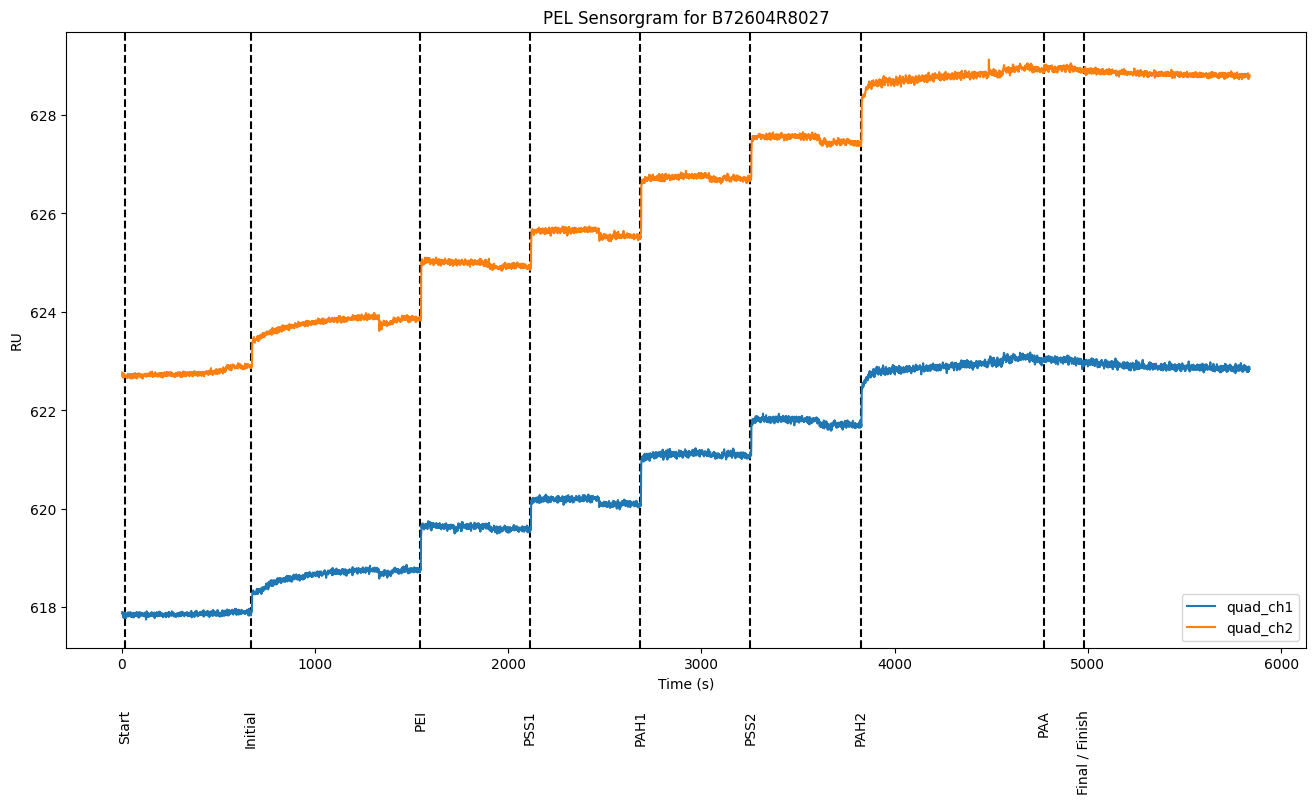

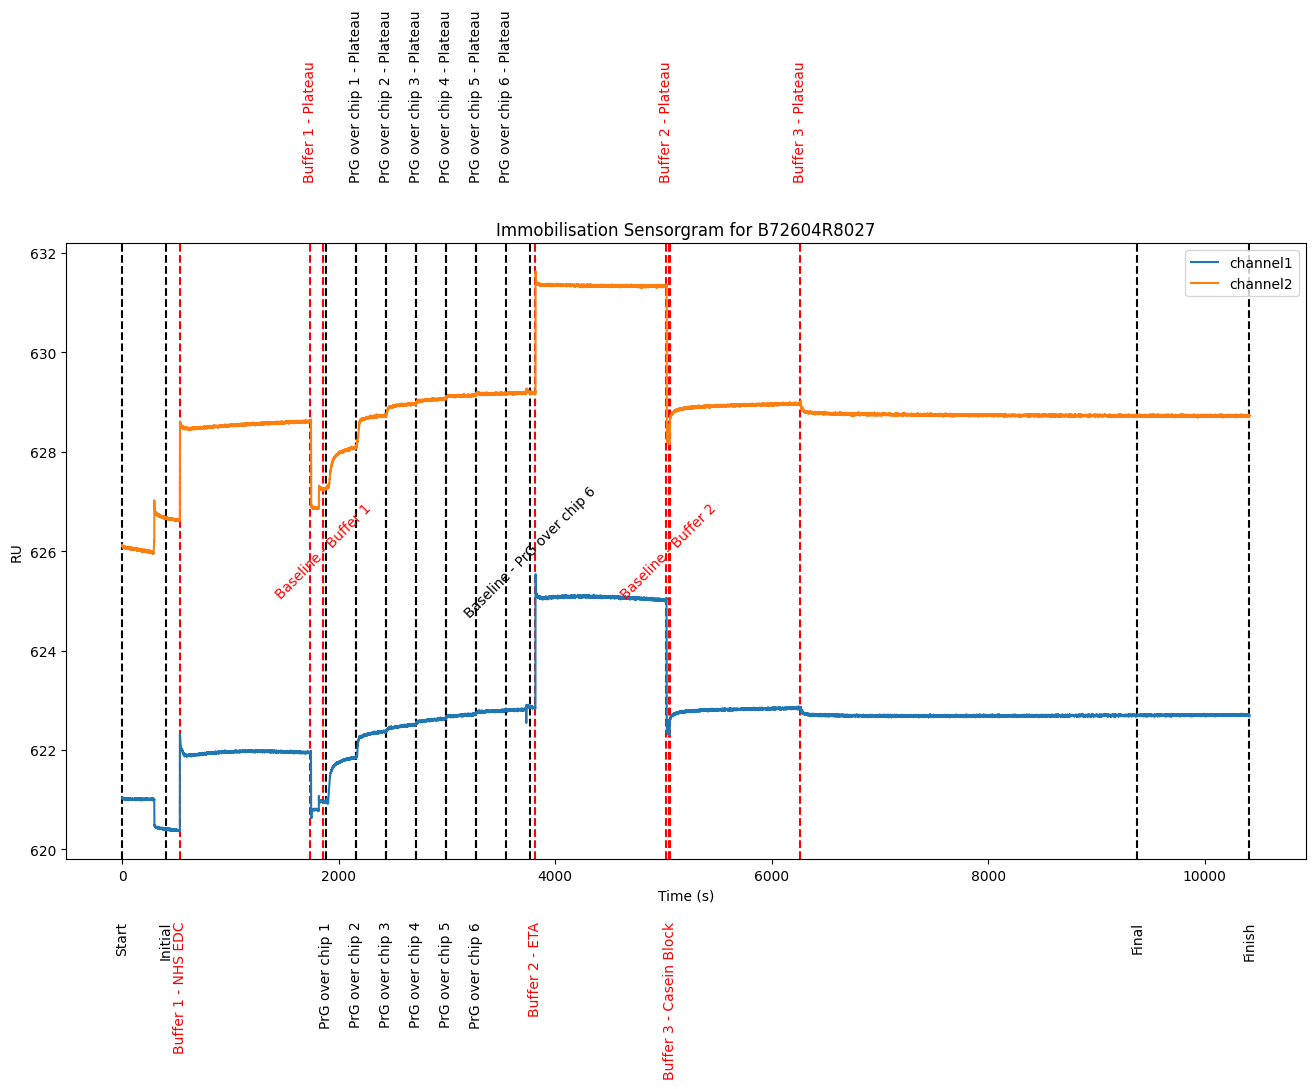

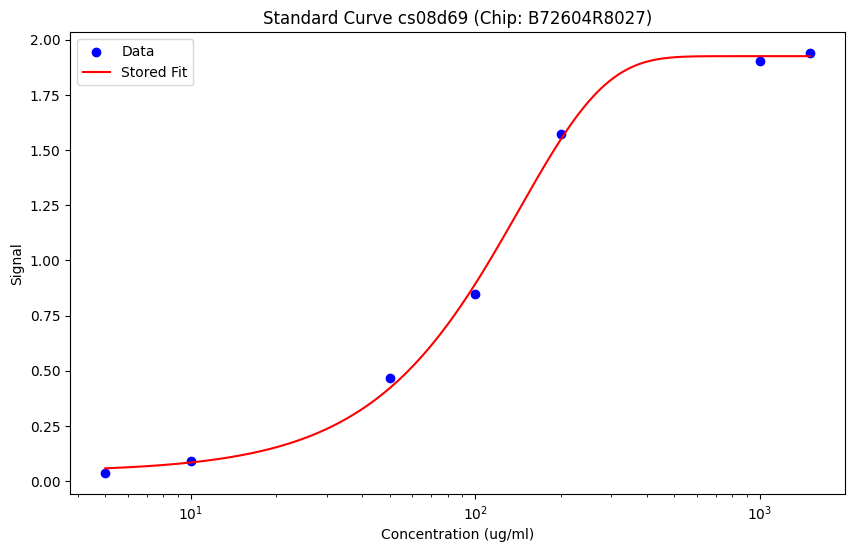

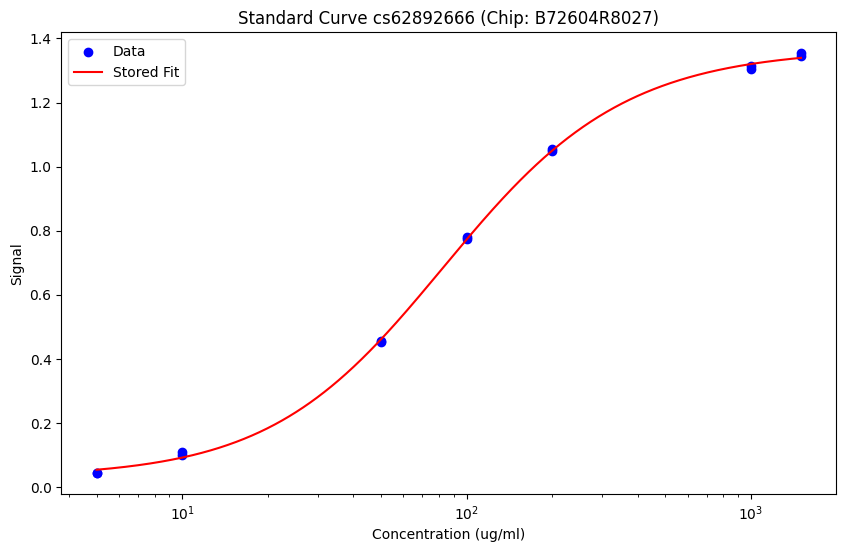

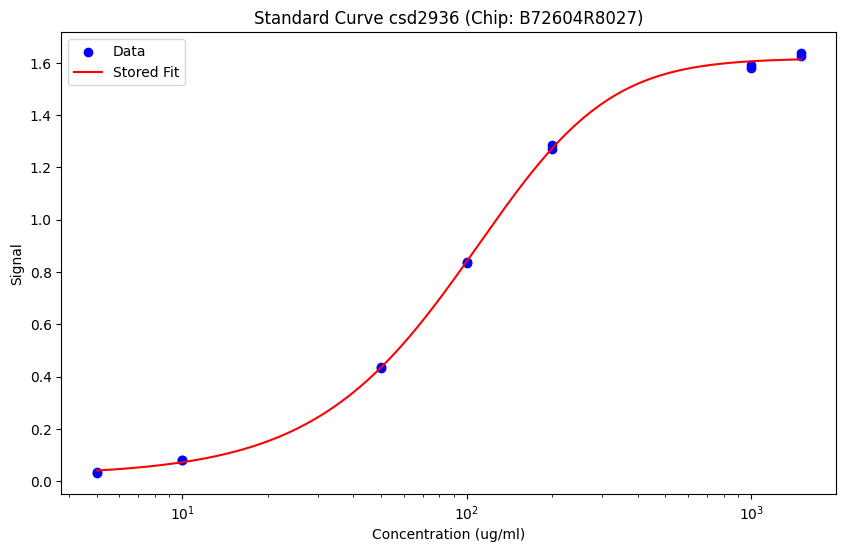

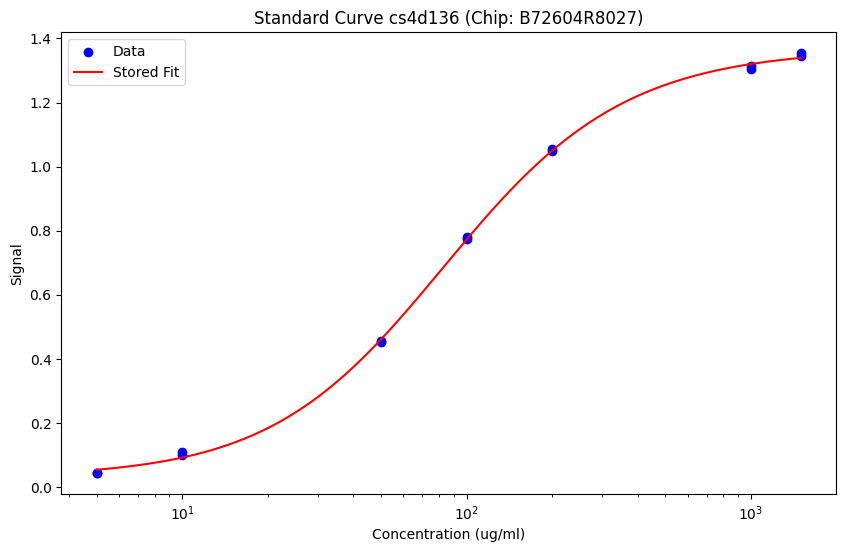

In [ ]:
for row in tables['pel_upload'].itertuples():

    if row.chip_id != 'B72604R8027':
        continue

    pel_sensorgram = bucket_data['Sensorgram'].get(row.sensorgram)

    flags_df = tables['flags'][tables['flags']['flags_id'] == row.flags_id]
    times = flags_df.iloc[0][1:].tolist()
    flags_list = flags_df.columns[1:].tolist()

    immob = tables['immob'][tables['immob']['chip_id'] == row.chip_id]

    if immob.empty:
        continue

    try:
        ref_key = immob['refPoly4'].iloc[0]
        amf_key = immob['amfFlags'].iloc[0]
        
        immob_sens = bucket_data['RefPoly4'].get(ref_key)
        immob_flags = bucket_data['AMF_FLAGS'].get(amf_key)
    except Exception as e:
        
        print(f'Failed to get immob files for row {row.Index}: {e}')
        continue

    sc = tables['standard_curves'][tables['standard_curves']['chip_id'] == row.chip_id]

    if pel_sensorgram.empty or sc.empty or immob.empty:
        continue

    for i in range(len(times)):
        if flags_list[i] == 'Finish':
            if times[i] == times[i-1]:
                times = times[:-1]
                flags_list = flags_list[:-1]
                flags_list[-1] = 'Final / Finish'
                break

    plot_flags_on_sensorgrams(pel_sensorgram, times, flags_list, title = 'PEL Sensorgram for ' + row.chip_id)
    plot_flags_on_sensorgrams(immob_sens, immob_flags['time'], immob_flags['information'], title = 'Immobilisation Sensorgram for ' + row.chip_id, colours=['r' if 'Buffer' in str(lbl) else 'k' for lbl in immob_flags['information']])

    def parse_delimited(s):
        '''Parses a delimited string field into a list of numeric values.

        Args:
            s (str): Serialised list from a standard-curve record.

        Returns:
            list[float]: Parsed numeric values.
        '''

        sep = '|' if '|' in str(s) else ','
        return [float(v) for v in str(s).split(sep)]

    data_points_SC = {}

    # Loops through each row in the dataframe
    for row in sc.itertuples():

        x = parse_delimited(row.x_csv)
        y = parse_delimited(row.y_csv)

        # Checks for mismatched coordinates
        if len(x) != len(y):
            print(f'Row {row.Index}: mismatched x/y lengths ({len(x)} vs {len(y)})')

        # Standardises the time string format and converts it to a datetime object
        time_str = str(row.time).strip()

        if '-' in time_str and ':' not in time_str:
            time_str = time_str.replace('-', ':')

        dt = pd.to_datetime(f'{row.date} {time_str}', format='%Y-%m-%d %H:%M:%S', errors='coerce')

        data_points_SC[row.standard_curve_uuid] = {
            'x': x,
            'y': y,
            'chip_id': row.chip_id,
            'fit_model': row.fit_model,
            'a': row.a,
            'b': row.b,
            'c': row.c,
            'd': row.d,
            'e': row.e,
            'datetime': dt
        }

    for key, data in data_points_SC.items():
        # Generates logarithmic points to plot the smooth fitted curve
        x_pts = np.logspace(np.log10(min(data['x'])), np.log10(max(data['x'])), 1000)

        # Evaluates the five-parameter logistic model using stored parameters
        if data['fit_model'] == '5PL':
            y_pts = five_pl(x_pts, data['a'], data['d'], data['c'], data['b'], data['e']) 
        else:
            y_pts = four_pl(x_pts, data['a'], data['d'], data['c'], data['b'])

        # Plots measured standard-curve points against the stored fit parameters
        plt.figure(figsize=(10, 6))
        plt.scatter(data['x'], data['y'], label='Data', color='blue')
        plt.plot(x_pts, y_pts, color='red', label='Stored Fit')

        plt.xscale('log')
        plt.title(f"Standard Curve {key} (Chip: {data['chip_id']})")
        plt.xlabel('Concentration (ug/ml)')
        plt.ylabel('Signal')
        plt.legend()
        plt.show()